In [1]:
import time
import h5py
import os
import pathlib
import logging
import subprocess
import re, os, stat
import argparse
import numpy as np
import scipy as sp
import pandas as pd
# from maria.weather import relative_to_absolute_humidity
from maria.constants import g
from maria import Quantity, Weather

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s.%(msecs)03d %(levelname)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("am")

# parser = argparse.ArgumentParser()
# parser.add_argument("--region", type=str, help="maria region")
# parser.add_argument("--tag", type=str)
# args = parser.parse_args()


In [2]:
from maria.weather import Weather

import os

# os.environ["MARIA_CACHE_DIR"] = "/users/tom/maria/data"
# os.environ["MARIA_CACHE_MAX_AGE"] = "1e10"


region = "south_pole"
region = "princeton"
# region = "boolardy"
# region = "chajnantor"

w = Weather(region,
            # pressure_level=100,
            diurnal=False,
            seasonal=False)

self = w

self


Weather:
  region: princeton
  time: Sep 28 12:06:56 -04:00 (America/New_York)
  altitude: 58 m
  pressure_level: 1011 hPa
  base_temperature: 286.2 K
  effective_temperature: 252.2 K
  pwv: 18.84 mm

In [3]:
self.pressure_level = 500
self


Weather:
  region: princeton
  time: Sep 28 12:06:35 -04:00 (America/New_York)
  altitude: 5682 m
  pressure_level: 500 hPa
  base_temperature: 258 K
  effective_temperature: 229.2 K
  pwv: 995.9 um

In [4]:
p = self.pressure_level.pin("hPa")
p

500 hPa

In [3]:
from maria.site import REGIONS

w = Weather(region, altitude=REGIONS.loc[region].min_altitude, diurnal=False, seasonal=False)
upper_pressure = w.pressure[np.digitize(w.pressure_level.Pa, w.pressure.Pa)].pin("hPa")

w = Weather(region, altitude=REGIONS.loc[region].max_altitude, diurnal=False, seasonal=False)
lower_pressure = w.pressure[np.digitize(w.pressure_level.Pa, w.pressure.Pa)].pin("hPa")

min_pressure = Quantity(10, "hPa")

side_pressure_level = [min_pressure, lower_pressure, upper_pressure]

side_pressure_level

[1 kPa, 975 hPa, 1000 hPa]

In [16]:
import arrow
import maria

effective_temperature_ranges = []


for region in maria.all_regions:
        
    w = Weather(region, altitude=REGIONS.loc[region].min_altitude, diurnal=False, seasonal=False)
    upper_pressure = w.pressure[np.digitize(w.pressure_level.Pa, w.pressure.Pa)].pin("hPa")
    
    w = Weather(region, altitude=REGIONS.loc[region].max_altitude, diurnal=False, seasonal=False)
    lower_pressure = w.pressure[np.digitize(w.pressure_level.Pa, w.pressure.Pa)].pin("hPa")
    
    min_pressure = Quantity(10, "hPa")
    
    side_pressure_level = [min_pressure, lower_pressure, upper_pressure]
    
    for pressure_level in side_pressure_level:
    
            for temperature_quantile in [0.1, 0.9]:
        
                w = Weather(region,
                            pressure_level=pressure_level,
                            quantiles={"temperature": temperature_quantile},
                            diurnal=False,
                            seasonal=False)
        
                effective_temperature_ranges.append(w.effective_temperature)
        
    print(region, min(effective_temperature_ranges), max(effective_temperature_ranges))

algonquin 231.4 K 255.4 K
boolardy 231.4 K 259.4 K
chajnantor 224.8 K 259.4 K
chiang_mai 224.8 K 261.2 K
dominion 224.8 K 261.2 K
effelsberg 224.8 K 261.2 K
green_bank 224.8 K 261.2 K
kitt_peak 224.8 K 261.2 K
mauna_kea 224.8 K 261.2 K
meerkat 224.8 K 261.2 K
metsahovi 224.8 K 261.2 K
minamimaki 224.8 K 261.2 K
mount_graham 224.8 K 261.2 K
narrabri 224.8 K 261.2 K
ngari 224.8 K 261.2 K
owens_valley 224.8 K 261.2 K
pic_de_bure 224.8 K 261.2 K
pico_veleta 224.8 K 261.2 K
princeton 224.8 K 261.2 K
qitai 224.8 K 261.2 K
san_agustin 224.8 K 261.2 K
san_antonio 224.8 K 261.2 K
san_basilio 224.8 K 261.2 K
sierra_negra 224.8 K 261.2 K
south_pole 213.3 K 261.2 K
summit_camp 213.3 K 261.2 K
teide 213.3 K 261.2 K
thule 213.3 K 261.2 K
warkworth 213.3 K 261.2 K
westford 213.3 K 261.2 K
yebes 213.3 K 261.2 K


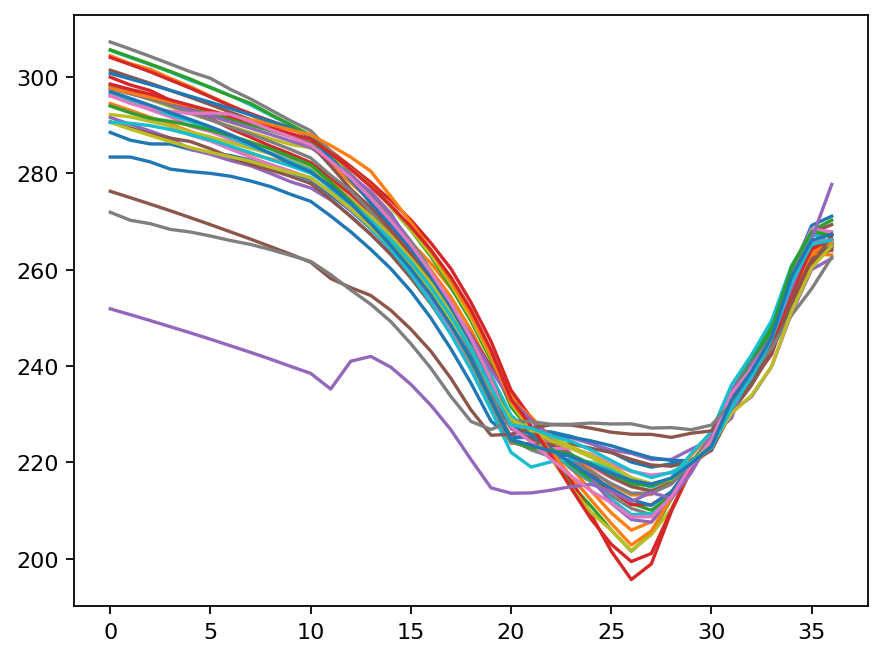

In [24]:
import matplotlib.pyplot as plt

for region in maria.all_regions:

    w = Weather(region,
                pressure_level=pressure_level,
                quantiles={"temperature": temperature_quantile},
                diurnal=False,
                seasonal=False)

    plt.plot(w.temperature.K)



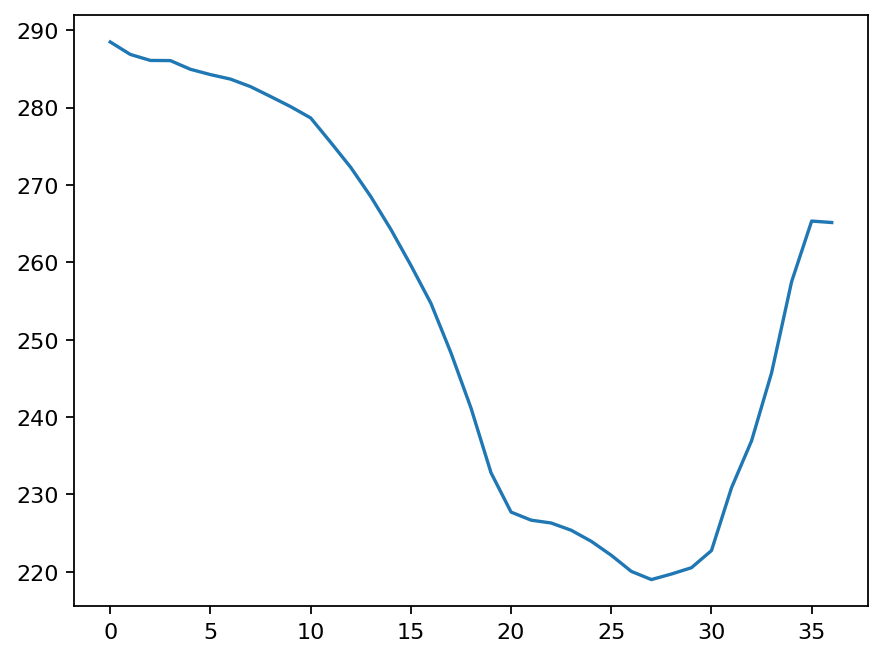

In [33]:
arrow.get().timestamp() + np.random.uniform(low=0, high=86400)

1790662481.310773

In [34]:
import matplotlib.pyplot as plt

from maria.utils.weather import compute_air_density


for pressure_level in [600, 10]:

    w = Weather(region,
                pressure_level=pressure_level,
                diurnal=False,
                seasonal=False)
    
    q_temperature = self.qdata["levels"]["temperature"]
    q_air_density = compute_air_density(self.qdata["metadata"]["side_pressure"], q_temperature, self.qdata["levels"]["humidity"])
    # T_eff = (air_density * self.qdata["levels"]["temperature"]).sum(axis=-1) / air_density.sum(axis=-1)
    
    z_samples = w.z_samples(dz=1e2)
    q_air_density_samples = sp.interpolate.interp1d(self.z.m, q_air_density[5])(z_samples)
    q_temperature_samples = sp.interpolate.interp1d(self.z.m, q_temperature[5])(z_samples)
    q_effective_temperature = (q_temperature_samples * q_air_density_samples).sum(axis=-1) / q_air_density_samples.sum(axis=-1)

    print(np.quantile(q_effective_temperature, q=[0, 0.5, 1]))

AttributeError: 'int' object has no attribute 'hPa'

In [37]:
w

Weather:
  region: south_pole
  time: Sep 29 04:59:42 +13:00 (Antarctica/South_Pole)
  altitude: 3141 m
  pressure_level: 650 hPa
  base_temperature: 241 K
  effective_temperature: 224.6 K
  pwv: 890.6 um

In [36]:
plt.imshow(q_effective_temperature)
plt.colorbar()

NameError: name 'q_effective_temperature' is not defined

In [31]:
q_air_density_samples.shape, q_temperature_samples.shape

((25, 24, 3132), (25, 24, 3132))

In [10]:
# self.effective_temperature

In [3]:
# base_temperature

In [4]:
def z_samples(self, dz: float = 1e1):
    return np.arange(self.altitude.m, self.z.m.max(), 1e1)

In [5]:
z = z_samples(self)

In [6]:
values = self(altitude=z, fields=["air_density", "temperature"])

In [13]:
# plt.plot(values["temperature"].K)
# plt.twinx().plot(values["air_density"].to("kg/m^3"), c="r")

In [119]:
T_eff = (values["temperature"] * values["air_density"]).sum() / values["air_density"].sum()
T_eff

217 K

In [120]:
(w.temperature * w.air_density).sum() / w.air_density.sum()

267.1 K

In [121]:
import matplotlib.pyplot as plt

from maria.utils.weather import compute_air_density



(11, 25, 24)

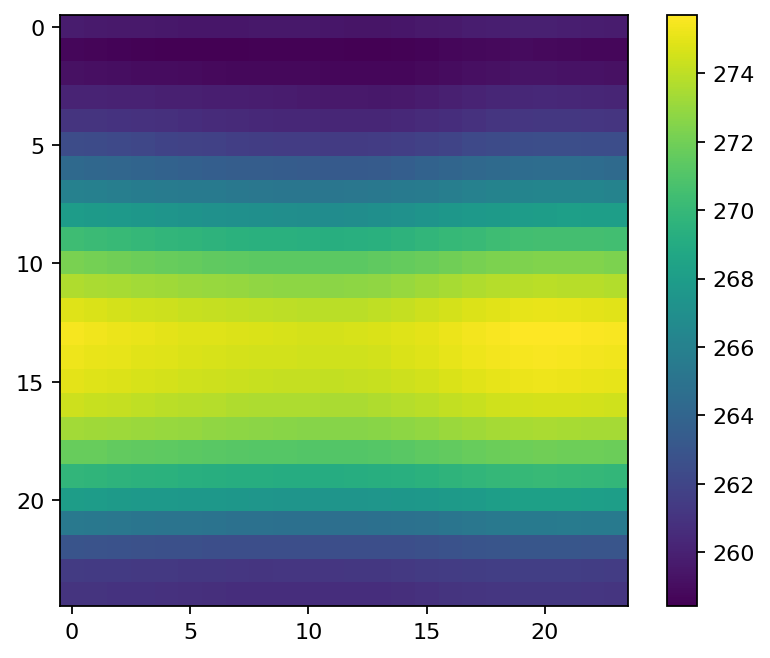

In [123]:

plt.imshow(T_eff[5])
plt.colorbar()

In [16]:
self.qdata["levels"]["temperature"]

(11, 25, 24, 37)

In [9]:
dir(w)

['__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'air_density',
 'altitude',
 'am_config',
 'base_pressure_index',
 'cache_path',
 'compute_am_spectrum',
 'compute_base_global_quantiles',
 'data',
 'dew_point',
 'layers',
 'local_time',
 'override',
 'pressure',
 'pressure_level',
 'pwv',
 'qdata',
 'quantiles',
 'region',
 'source',
 'time',
 'timezone',
 'utc_day_hour',
 'utc_year_day',
 'vapor_pressure',
 'water_vapor',
 'wind_bearing',
 'z']

In [12]:
self = w


self.qdata["air_density"]

KeyError: 'air_density'

In [3]:
ams = w.compute_am_spectrum("/users/tom/am-14.0/src/am", )

# print(ams["stderr"])

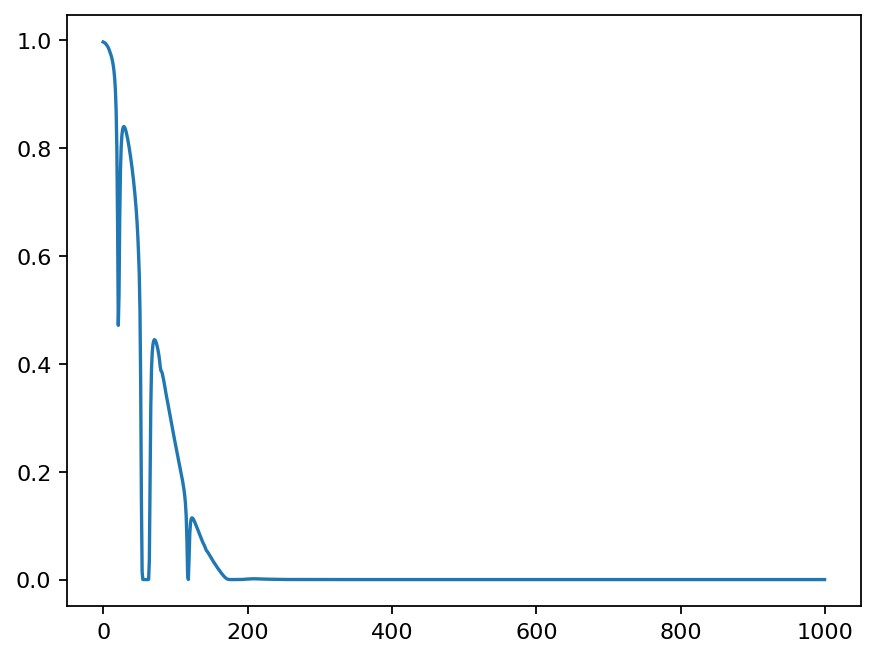

In [17]:
import matplotlib.pyplot as plt

plt.plot(np.exp(-ams["opacity"]))

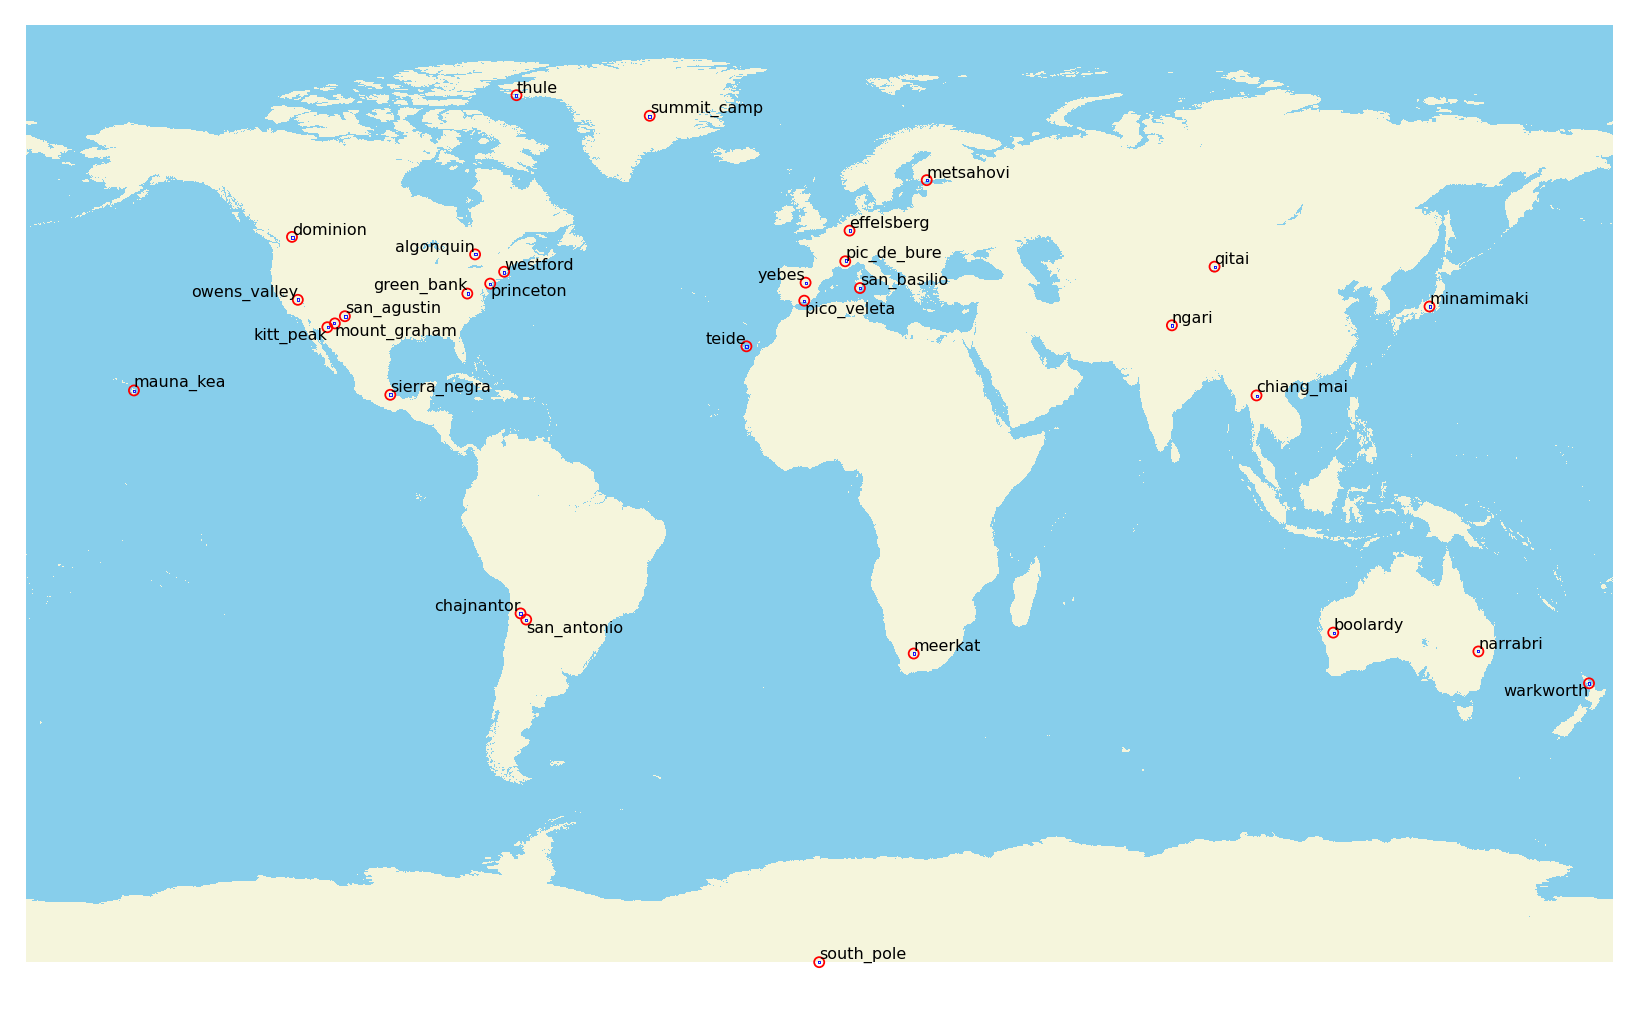

In [3]:
import maria

maria.site.plot_all_regions()

In [1]:

region = "algonquin"
tag = "v2"

# spec_ranges = [(1e6, 1e7, 1e-1), # 1 MHz to 10 MHz
#                (1e7, 1e8, 1e-1), # 10 MHz to 100 MHz
#                (1e8, 1e9, 1e-2), # 100 MHz to 1 GHz
#                (1e9, 1e10, 1e-3), # 1 GHz to 10 GHz
#                (1e10, 1e11, 1e-4), # 10 GHz to 100 GHz
#                (1e11, 1e12, 1e-4), # 100 GHz to 1 THz
#                (1e12, 15e12, 1e-2)] # 1 THz to 15 THz

spec_range_list = [(1e6, 1e7, 1e5), # 1 MHz to 10 MHz
                   (1e7, 1e12, 1e7), # 10 MHz to 1 THz
                   # (1e11, 1e12, 1e8), # 1 MHz to 10 MHz
                   # (1e7, 1e12, 1e7), # 10 MHz to 1 THz
                   (1e12, 15e12, 1e9)] # 1 THz to 15 THz

spec_ranges = []
nu = np.empty(0)
cum_n = 0
for i, (nu_min, nu_max, nu_step) in enumerate(spec_range_list):

    # nu_step = rel_step * nu_min
    # nu_max = nu_max if i + 1 == len(spec_ranges) else nu_max - nu_step
    
    range_nu = np.arange(nu_min, nu_max + 1e0, step=nu_step)
    spec_ranges.append({"nu_min": Quantity(nu_min, "Hz"), 
                        "nu_max": Quantity(nu_max, "Hz"), 
                        "nu_step": Quantity(nu_step, "Hz"), 
                        "n": len(range_nu),
                        "nu_slice": slice(cum_n, cum_n + len(range_nu), 1)
                       })
    cum_n += len(range_nu)
    nu = np.r_[nu, range_nu]


# for running on della
MARIA_PATH = "/users/tom/maria"
AM_PATH = "/users/tom/am-14.0/src/am"

REGIONS = pd.read_csv("/users/tom/maria/data/regions.csv", index_col=0)
region_entry = REGIONS.loc[region]

write_dir = f"{MARIA_PATH}/raw_spectra/{tag}"
assert os.path.isdir(write_dir)
write_path = f"{write_dir}/{region}.h5"


NameError: name 'np' is not defined

In [3]:
spec_ranges

[{'nu_min': 1 MHz,
  'nu_max': 10 MHz,
  'nu_step': 100 kHz,
  'n': 91,
  'nu_slice': slice(0, 91, 1)},
 {'nu_min': 10 MHz,
  'nu_max': 1 THz,
  'nu_step': 10 MHz,
  'n': 100000,
  'nu_slice': slice(91, 100091, 1)},
 {'nu_min': 1 THz,
  'nu_max': 15 THz,
  'nu_step': 1 GHz,
  'n': 14001,
  'nu_slice': slice(100091, 114092, 1)}]

In [53]:
from maria.weather import Weather
from maria.site.region import REGIONS
from maria.weather.weather import water_density
from maria.units import Quantity


region = "chajnantor"

w = Weather(region, altitude=REGIONS.loc[region].min_altitude, diurnal=False, seasonal=False)
upper_pressure = w.pressure[np.digitize(w.pressure_level.Pa, w.pressure.Pa)].pin("hPa")

w = Weather(region, altitude=REGIONS.loc[region].max_altitude, diurnal=False, seasonal=False)
lower_pressure = w.pressure[np.digitize(w.pressure_level.Pa, w.pressure.Pa)].pin("hPa")

min_pressure = Quantity(10, "hPa")

side_pwv = Quantity([0, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0], "mm")
el_samples = np.array([90, 60, 40, 25, 15, 10, 5])

side_csc_el = 1 / np.sin(np.radians(el_samples))
side_pressure_level = [min_pressure, lower_pressure, upper_pressure]

side_temperature_offset = Quantity([-10, 10], "K")

print(side_csc_el)
print(side_pwv)
print(side_pressure_level)
print(side_temperature_offset)

[ 1.          1.15470054  1.55572383  2.36620158  3.86370331  5.75877048
 11.47371325]
[ 0.   0.2  0.5  1.   2.   5.  10.  20.  50. ] mm
[1 kPa, 450 hPa, 600 hPa]
[-10.  10.] K


In [55]:
# plt.plot(side_csc_el)

In [7]:
data_shape = (
    len(side_pressure_level),
    len(side_temperature_offset),
    len(side_pwv),
    len(side_csc_el),
    sum([spec_range["n"] for spec_range in spec_ranges]),
)

print(data_shape)

data = {
    "log_temperature_rayleigh_jeans": np.zeros(data_shape),
    "opacity": np.zeros(data_shape),
    "path_delay": np.zeros(data_shape),
}

(3, 2, 9, 7, 114092)


In [54]:
# 3 * 2 * 9 * 7

In [9]:
# the important this is w_eff T_eff = \int \rho(z) T(z) dz

# so we have fluctuation
# \delta w_eff = \int (\rho(z) dT(z) + d\rho(z) T(z))
# 

# w_eff is the 


In [10]:
# \int T(z) \kappa(z)

In [11]:
from maria.io.logging import DEFAULT_BAR_FORMAT
DEFAULT_BAR_FORMAT = "{l_bar}{bar:10}{r_bar}{postfix:100}"

In [13]:
config_index_list = []
for pressure_level_index, pressure_level in enumerate(side_pressure_level):
    for temperature_offset_index, temperature_offset in enumerate(side_temperature_offset):
        for pwv_index, pwv in enumerate(side_pwv):
            for csc_el_index, csc_el in enumerate(side_csc_el):
                config_index_list.append({
                    "pressure_level": pressure_level_index,
                    "temperature_offset": temperature_offset_index,
                    "pwv": pwv_index,
                    "csc_el": csc_el_index,
                })

config_index_list [0]

{'pressure_level': 0, 'temperature_offset': 0, 'pwv': 0, 'csc_el': 0}

In [58]:
print(w)

w.altitude = Quantity(7, "km")

print(w)

Weather:
  region: chajnantor
  time: Sep 28 01:30:49 -03:00 (America/Santiago)
  altitude: 6 km
  pressure_level: 490.1 hPa
  base_temperature: 264.5 K
  effective_temperature: 230.5 K
  pwv: 660.2 um
Weather:
  region: chajnantor
  time: Sep 28 01:30:49 -03:00 (America/Santiago)
  altitude: 7 km
  pressure_level: 490.1 hPa
  base_temperature: 257.8 K
  effective_temperature: 226.2 K
  pwv: 369 um


In [65]:


def vapor_pressure(temperature, humidity):  # units are (°K, %)
    T = temperature - 273.15  # in °C
    a, b, c = 611.21, 17.67, 238.88  # units are Pa, ., °C
    gamma = np.log(np.maximum(humidity, 1e-20)) + b * T / (c + T)
    return a * np.exp(gamma)


def saturation_pressure(temperature):  # units are (°K, %)
    T = temperature - 273.15  # in °C
    a, b, c = 611.21, 17.67, 238.88  # units are Pa, ., °C
    return a * np.exp(b * T / (c + T))


def dew_point(temperature, humidity):  # units are (°K, %)
    a, b, c = 611.21, 17.67, 238.88  # units are Pa, ., °C
    p_vap = vapor_pressure(temperature, humidity)
    return c * np.log(p_vap / a) / (b - np.log(p_vap / a)) + 273.15


def dew_point_to_relative_humidity(temperature, dew_point):
    T, DP = temperature - 273.15, dew_point - 273.15  # in °C
    b, c = 17.67, 238.88
    return 1e2 * np.exp(b * DP / (c + DP) - b * T / (c + T))


def compute_air_density(pressure, temperature, humidity):
    vp = vapor_pressure(temperature, humidity)
    return vp / (WATER_VAPOR_SPECIFIC_GAS_CONSTANT * temperature) + (pressure - vp) / (
        DRY_AIR_SPECIFIC_GAS_CONSTANT * temperature
    )


def relative_to_absolute_humidity(temperature, humidity):
    return humidity * saturation_pressure(temperature) / (461.5 * temperature)


def absolute_to_relative_humidity(temperature, abs_hum):
    return 461.5 * temperature * abs_hum / saturation_pressure(temperature)


class Air:

    def __init__(self, temperature: float, humidity: float, pressure: float):
        self.temperature = Quantity(temperature, "K")
        self.pressure = Quantity(pressure, "Pa")
        self.humidity = humidity



# a = Air(w.temperature, w.humidity, w.pressure)



In [249]:
from tqdm import tqdm

config_pbar = tqdm(config_index_list, ncols=250)

for config_index in config_pbar:

    pressure_level = side_pressure_level[config_index["pressure_level"]]
    temperature_offset = side_temperature_offset[config_index["temperature_offset"]]
    pwv = side_pwv[config_index["pwv"]]
    csc_el = side_csc_el[config_index["csc_el"]]
    
    w = Weather(region,  
        pressure_level=pressure_level,
        diurnal=False,
        seasonal=False,
        override={"pwv": pwv})

    w.data["levels"]["temperature"] += Quantity(temperature_offset, "K")

    for spec_range_index, spec_range in enumerate(spec_ranges):

        config_pbar.set_postfix(pressure_level=w.pressure_level,
                                csc_el=csc_el, 
                                pwv=pwv,
                                temperature_offset=temperature_offset,
                                spec_range=(spec_range["nu_min"], spec_range["nu_max"]))

        spec = w.compute_am_spectrum(am_path="/users/tom/am-14.0/src/am",
                                     nu_min=spec_range["nu_min"], 
                                     nu_max=spec_range["nu_max"], 
                                     nu_step=spec_range["nu_step"], 
                                     el=np.degrees(np.arcsin(1/csc_el)))

        total_slice = tuple([config_index["pressure_level"], 
                             config_index["temperature_offset"], 
                             config_index["pwv"], 
                             config_index["csc_el"], 
                             spec_range["nu_slice"]])

        data["log_temperature_rayleigh_jeans"][total_slice] = np.log(spec["temperature_rayleigh_jeans"].K_RJ)
        data["opacity"][total_slice] = spec["opacity"]
        data["path_delay"][total_slice] = spec["path_delay"].m

                # assert False


    

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 378/378 [1:14:15<00:00, 11.79s/it, csc_el=11.5, pressure_level=100 hPa, pwv=50 mm, spec_range=(1 THz, 15 THz), temperature_offset=10 K]


In [657]:
np.degrees(np.arcsin(1/side_csc_el))

array([90., 60., 40., 25., 15., 10.,  5.])

In [13]:
w.time

<Arrow [2026-09-27T22:56:53.903495+00:00]>

Weather:
  region: chajnantor
  time: Sep 27 19:56:53 -03:00 (America/Santiago)
  altitude: 4.398 km
  pressure_level: 600 hPa
  base_temperature: 275.3 K
  pwv: 500 um

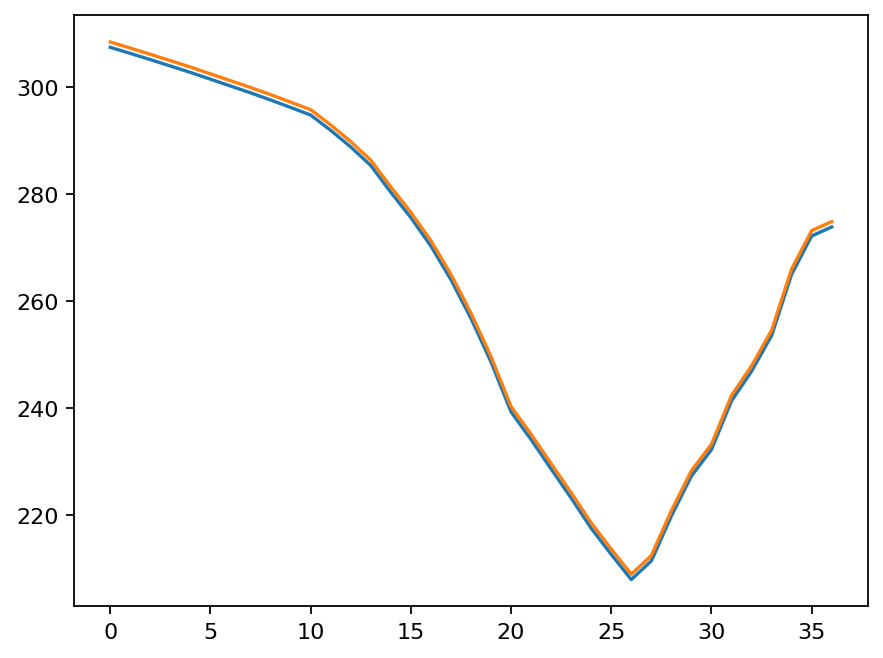

In [683]:

s1 = w.compute_am_spectrum(am_path="/users/tom/am-14.0/src/am", nu_min=50e9, nu_max=400e9, nu_step=1e8, el=90)
# plt.plot(s["nu"].GHz, s["temperature_rayleigh_jeans"].K_RJ)

plt.plot(w.data["levels"]["temperature"].K)

w.data["levels"]["temperature"] += Quantity(1, "K")
s2 = w.compute_am_spectrum(am_path="/users/tom/am-14.0/src/am", nu_min=50e9, nu_max=400e9, nu_step=1e8, el=90)
# plt.plot(s["nu"].GHz, s["temperature_rayleigh_jeans"].K_RJ)

plt.plot(w.data["levels"]["temperature"].K)
# plt.plot(s["nu"].GHz, np.exp(-s["opacity"]))

In [682]:
plt.plot(w.data["levels"]["temperature"].K)

[-10.  10.] K

In [676]:
side_pwv[2], side_csc_el[0]

(500 um, np.float64(1.0))

(1000000000000.0, 2000000000000.0)

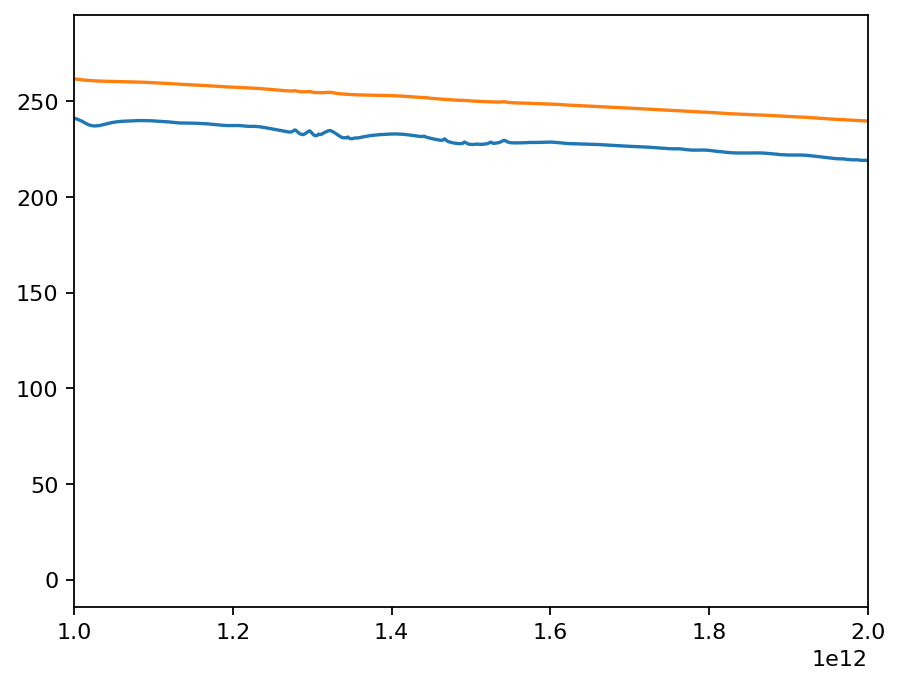

In [685]:
plt.plot(nu, spec[0, 0, 4, 0])
plt.plot(nu, spec[0, 1, 4, 0])

plt.xlim(1e12, 2e12)

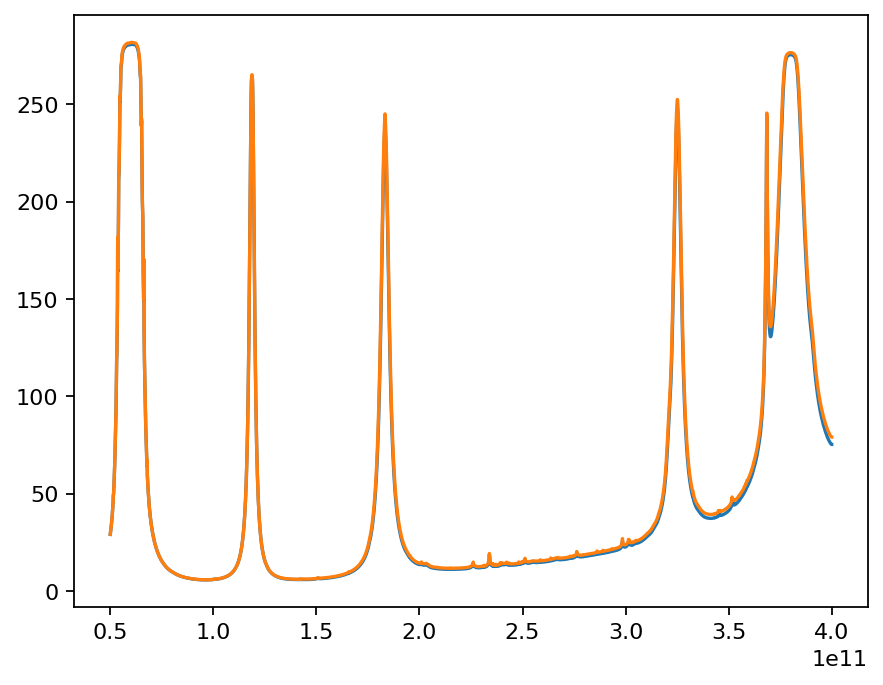

In [689]:
plt.plot(s1["nu"].Hz, s1["temperature_rayleigh_jeans"].K_RJ)
plt.plot(s2["nu"].Hz, s2["temperature_rayleigh_jeans"].K_RJ)
# plt.xlim(1e12, 2e12)

In [642]:
s1

{'nu': [ 50.   50.1  50.2 ... 399.8 399.9 400. ] GHz,
 'temperature_rayleigh_jeans': [29.74793 30.51045 31.31834 ... 97.7013  97.59019 97.57986] K_RJ,
 'opacity': array([0.1316404, 0.1352369, 0.139063 , ..., 0.503316 , 0.502697 ,
        0.502849 ], shape=(3501,)),
 'path_delay': [1.608333 1.608473 1.608364 ... 1.604843 1.604843 1.604826] m}

In [595]:
pwv = Quantity(2, "mm")

w = Weather(region,  
        pressure_level=pressure_level,
        diurnal=False,
        seasonal=False,
        override={"pwv": pwv})


w.data["levels"]["temperature"] += Quantity(-temperature_offset, "K")

print(w.am_config(nu_min, nu_max, nu_step, el=np.radians(45)))

f 1000000000000.0 Hz 15000000000000.0 Hz 1000000000.0 Hz
output f Hz Trj K tau neper L m
tol 0
za 89.21460183660255 deg
T0 0 K


layer
Pbase 100.000 Pa
Tbase 253.805 K
column h2o 0.0 um_pwv
column o3 vmr 3.75354066051159e-09
column dry_air vmr

layer
Pbase 200.000 Pa
Tbase 252.125 K
column h2o 4.169360868267513 um_pwv
column o3 vmr 1.1264817289339629e-08
column dry_air vmr

layer
Pbase 300.000 Pa
Tbase 244.958 K
column h2o 6.705676625240594 um_pwv
column o3 vmr 2.3454127375070282e-08
column dry_air vmr

layer
Pbase 500.000 Pa
Tbase 233.505 K
column h2o 15.756387899063581 um_pwv
column o3 vmr 5.517161894156668e-08
column dry_air vmr

layer
Pbase 700.000 Pa
Tbase 226.853 K
column h2o 13.611691132422779 um_pwv
column o3 vmr 9.0721153635324e-08
column dry_air vmr

layer
Pbase 1000.000 Pa
Tbase 221.322 K
column h2o 19.34691341176435 um_pwv
column o3 vmr 1.386047432324252e-07
column dry_air vmr

layer
Pbase 2000.000 Pa
Tbase 212.220 K
column h2o 61.50284223817551 um_pwv
column o3 vmr 2.07263

In [597]:
# s = w.compute_am_spectrum(am_path="/users/tom/am-14.0/src/am",nu_min=50e9, nu_max=300e9, nu_step=1e9, el=np.radians(45))
# plt.plot(s["temperature_rayleigh_jeans"].K_RJ)

In [261]:
spec["temperature_rayleigh_jeans"]

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [259]:
data["log_temperature_rayleigh_jeans"] = np.log(data["temperature_rayleigh_jeans"])

In [251]:
w

Weather:
  region: chajnantor
  time: Sep 26 19:49:59 -03:00
  altitude: 16.51 km
  pressure_level: 100 hPa
  base_temperature: 207.9 K
  pwv: 176.9 mm

In [326]:
with h5py.File(f"/users/tom/maria/raw_spectra/v2/{region}.h5", "w") as f:
    for field in data:
        f.create_dataset(field, data=data[field], dtype=float)

In [327]:
import matplotlib.pyplot as plt

In [432]:
key = "opacity"
key = "log_temperature_rayleigh_jeans"

key = "path_delay"

tolerance = {
    "temperature_rayleigh_jeans": 1e-1,
    "path_delay": 1e-4,
    "opacity": 1e-2,
}

In [392]:
for field in tolerance:
    
    nu_index_nesting = np.zeros_like(nu)
    max_nesting = int(np.log2(len(nu)) + 1)
    for nesting in range(max_nesting):
        nu_index_nesting[np.arange(len(nu)) % (2**nesting) == 0] = nesting
    nu_index_nesting[[0, -1]] = np.inf
    
    include_nu_mask = np.ones_like(nu, dtype=bool)


    

In [394]:
parity = 0

spec = data[field]

candidate_mask = np.array([True, *(np.arange(include_nu_mask.sum() - 2) % 2 == parity), True])

pred_spec = sp.interpolate.interp1d(nu[include_nu_mask][candidate_mask], spec[..., include_nu_mask][..., candidate_mask], axis=-1)(nu)

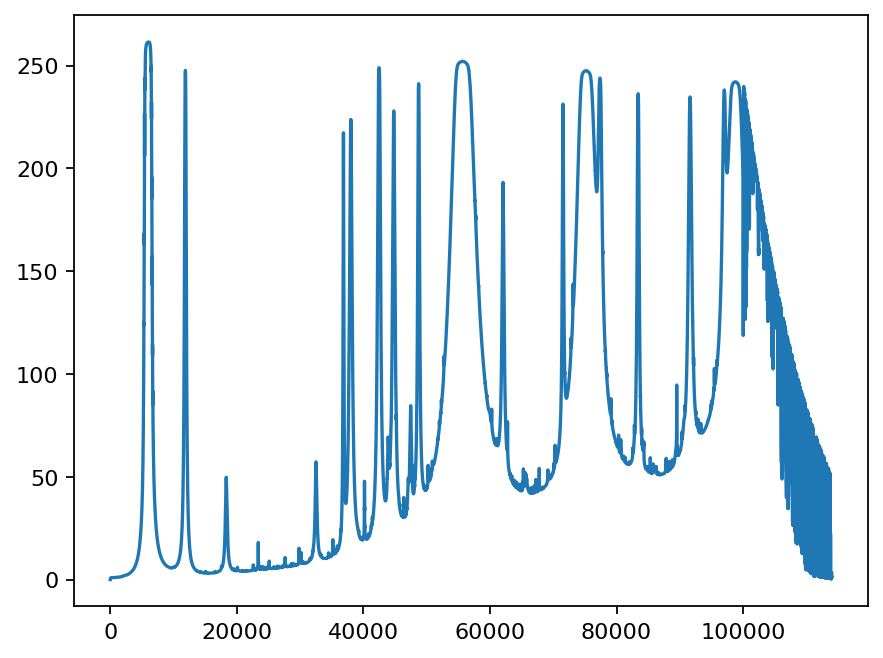

In [654]:
plt.plot(spec[0,0,1,1])

In [395]:
max_abs_error = np.abs(spec - pred_spec).max(axis=(0, 1, 2, 3))

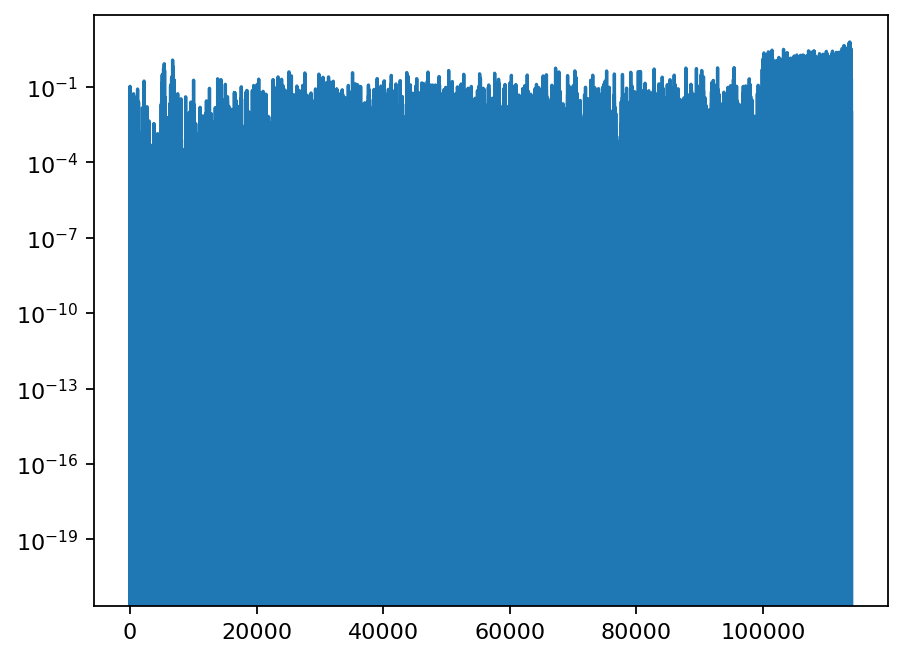

In [398]:
plt.plot(max_abs_error)
plt.yscale("log")

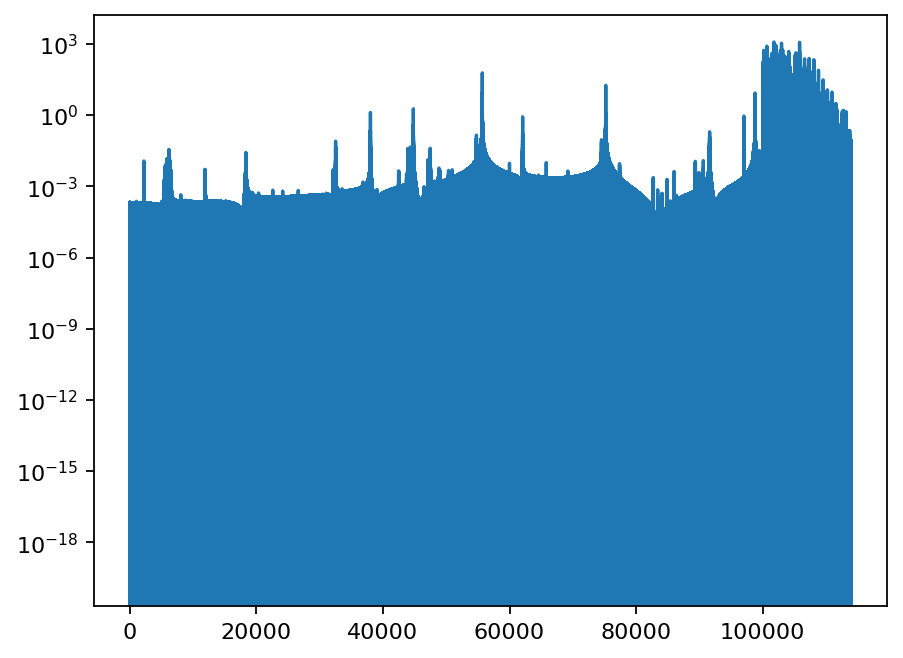

In [387]:
plt.plot(max_abs_error)
plt.yscale("log")

In [411]:
with h5py.File(f"/tmp/{region}.h5", "w") as f:        
            
    for field in tolerance:
        
        nu_index_nesting = np.zeros_like(nu)
        max_nesting = int(np.log2(len(nu)) + 1)
        for nesting in range(max_nesting):
            nu_index_nesting[np.arange(len(nu)) % (2**nesting) == 0] = nesting
        nu_index_nesting[[0, -1]] = np.inf
        
        include_nu_mask = np.ones_like(nu, dtype=bool)
        
        for nesting in trange(max_nesting):
            
            nesting_mask = nu_index_nesting != nesting
        
            spec = data[field]
            pred_spec = sp.interpolate.interp1d(nu[include_nu_mask & nesting_mask], spec[..., include_nu_mask & nesting_mask], axis=-1)(nu)
            abs_error = np.abs(spec - pred_spec)
        
            inaccurate = (abs_error > tolerance[field]).sum(axis=(0, 1, 2, 3)) > 0
            
            include_nu_mask &= (inaccurate | (include_nu_mask & nesting_mask))

        print(field, include_nu_mask.sum() / include_nu_mask.size)

        f.create_dataset(field, data=data[field][..., include_nu_mask], dtype=np.float32)


 24%|██████████▎                                 | 4/17 [00:02<00:08,  1.58it/s]


KeyboardInterrupt: 

In [541]:
key = "opacity"
key = "log_temperature_rayleigh_jeans"

key = "path_delay"

tolerance = {
    
    "opacity": 1e-2,
    "path_delay": 1e-3,
    "temperature_rayleigh_jeans": 1e-2,
}

In [542]:
with h5py.File(f"/tmp/{region}.h5", "w") as f:        
            
    for field in tolerance:
        
        nu_index_nesting = np.zeros_like(nu)
        max_nesting = int(np.log2(len(nu)) + 1)
        for nesting in range(max_nesting):
            nu_index_nesting[np.arange(len(nu)) % (2**nesting) == 0] = nesting
        nu_index_nesting[[0, -1]] = np.inf
        
        nu_indices = np.where(nu)[0]
        
        spec = data[field]

        pbar = trange(12, desc=field)
        
        for loop in pbar:

            for parity in [0, 1]:
                
                candidate = np.array([False, *(np.arange(len(nu_indices) - 2) % 2 == parity), False])
                pred_spec = sp.interpolate.interp1d(nu[nu_indices][~candidate], spec[..., nu_indices][..., ~candidate], axis=-1)(nu[nu_indices])
                abs_error = np.abs(spec[..., nu_indices] - pred_spec)
                rel_error = abs_error / np.abs(spec[..., nu_indices])
        
                accurate = rel_error.max(axis=(0, 1, 2, 3)) < tolerance[field]
                redundant = accurate & candidate
                nu_indices = nu_indices[~redundant]

                pbar.set_postfix(n=len(nu_indices))
                
        print(field, len(nu_indices), len(nu_indices) / len(nu))

        f.create_group(field)
        f[field].create_dataset("values", data=data[field][..., nu_indices], dtype=np.float32, compression="gzip")
        # f[field].create_dataset("values", data=data[field][..., nu_indices], dtype=np.float32, compression="gzip")


opacity: 100%|█████████████████████████| 12/12 [00:04<00:00,  2.48it/s, n=25665]


opacity 25665 0.22512960412627958


path_delay: 100%|██████████████████████| 12/12 [00:05<00:00,  2.06it/s, n=35256]


path_delay 35256 0.30926044508381506


temperature_rayleigh_jeans: 100%|██████| 12/12 [00:04<00:00,  2.71it/s, n=23985]


temperature_rayleigh_jeans 23985 0.21039289129042726


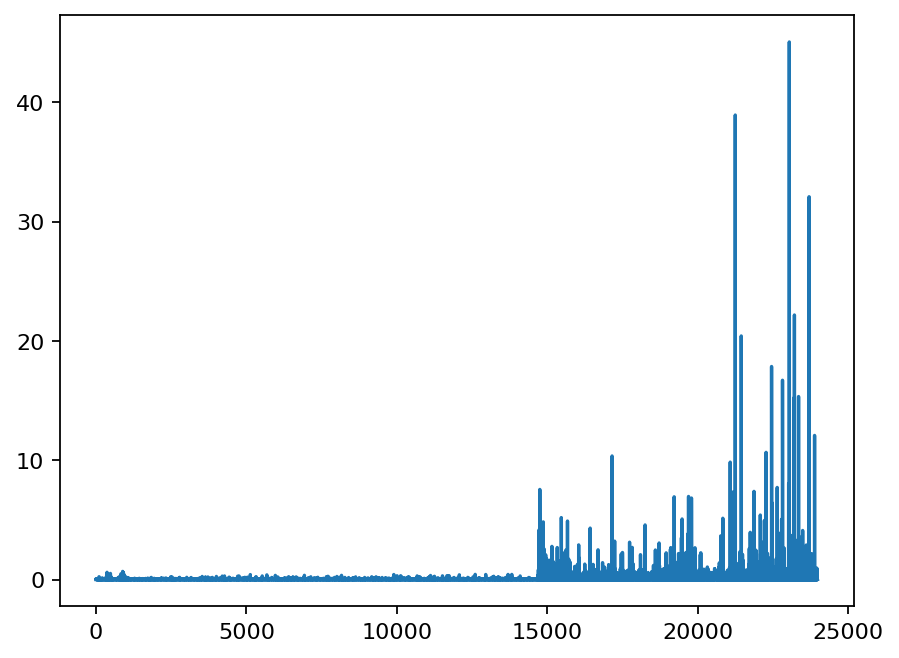

In [543]:
plt.plot(rel_error.max(axis=(0, 1, 2, 3)))

[]

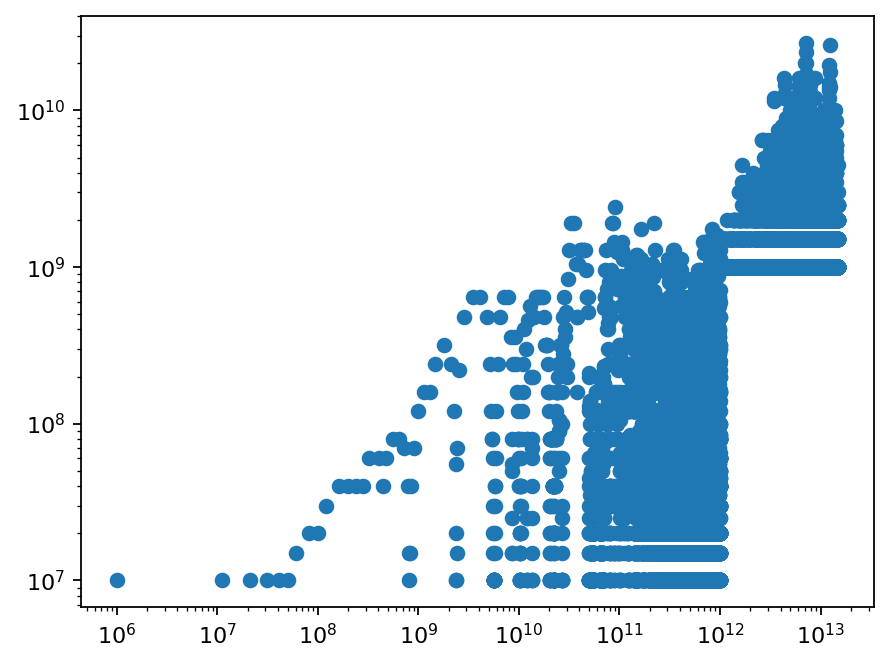

In [544]:
plt.scatter(nu[nu_indices], np.gradient(nu[nu_indices]))
plt.loglog()

In [545]:
data["path_delay"].shape

(3, 2, 9, 7, 114001)

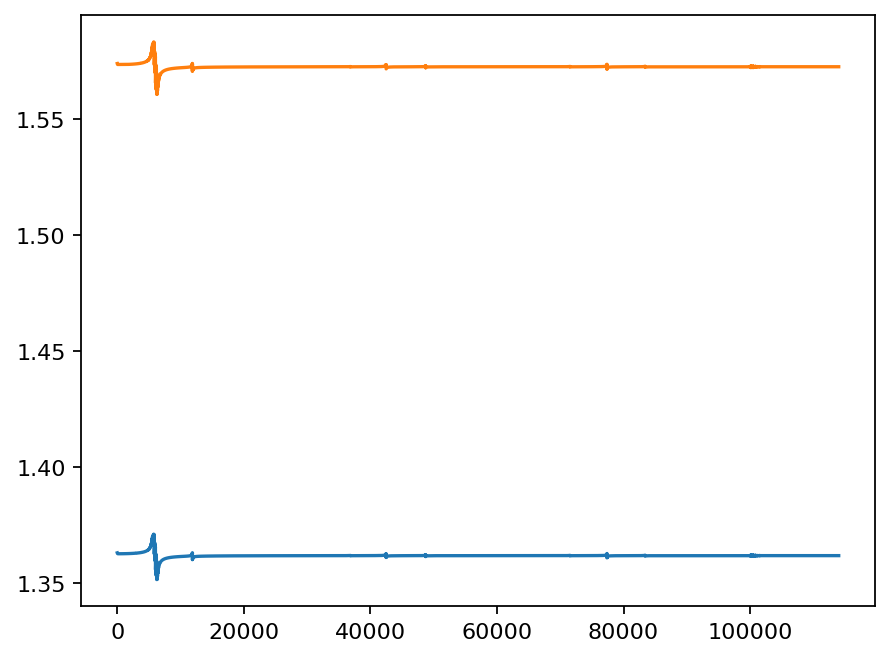

In [546]:
plt.plot(data["path_delay"][0, 0, 0, 0])
plt.plot(data["path_delay"][0, 0, 0, 1])

In [561]:
spec[0, 1, 1, 1].max()

np.float64(281.2174)

In [562]:
spec[0, 0, 1, 1].max()

np.float64(261.4746)

In [599]:
side_pressure_level

[600 hPa, 450 hPa, 10 kPa]

(90000000000.0, 500000000000.0)

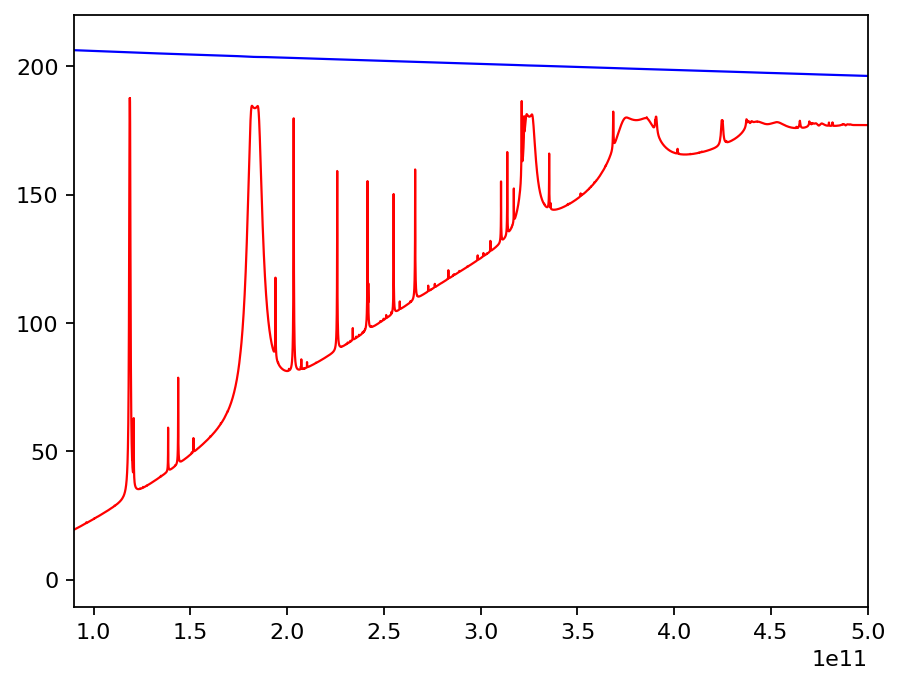

In [600]:
plt.plot(nu, spec[-1, 0, -1, 1], c="r", lw=1e0)
plt.plot(nu, spec[-1, 1, -1, 1], c="b", lw=1e0)
# plt.scatter(nu[nu_indices], spec[0, 0, -1, 1, nu_indices], s=1)

plt.xlim(90e9, 500e9)
# plt.ylim(0, 10)

In [553]:
side_temperature_offset

[-10.  10.] K

In [420]:
pred_spec.shape

(3, 2, 9, 7, 76203)

In [500]:
!ls -lah /tmp/*.h5

-rw-r--r--  1 tom  wheel    73M Sep 26 23:38 /tmp/chajnantor.h5


In [336]:

    # assert False

100%|███████████████████████████████████████████| 17/17 [00:10<00:00,  1.64it/s]


In [337]:
include_nu_mask.sum() / include_nu_mask.size

np.float64(0.8508697292129016)

In [338]:
include_nu_mask

array([ True,  True, False, ...,  True,  True,  True], shape=(114001,))

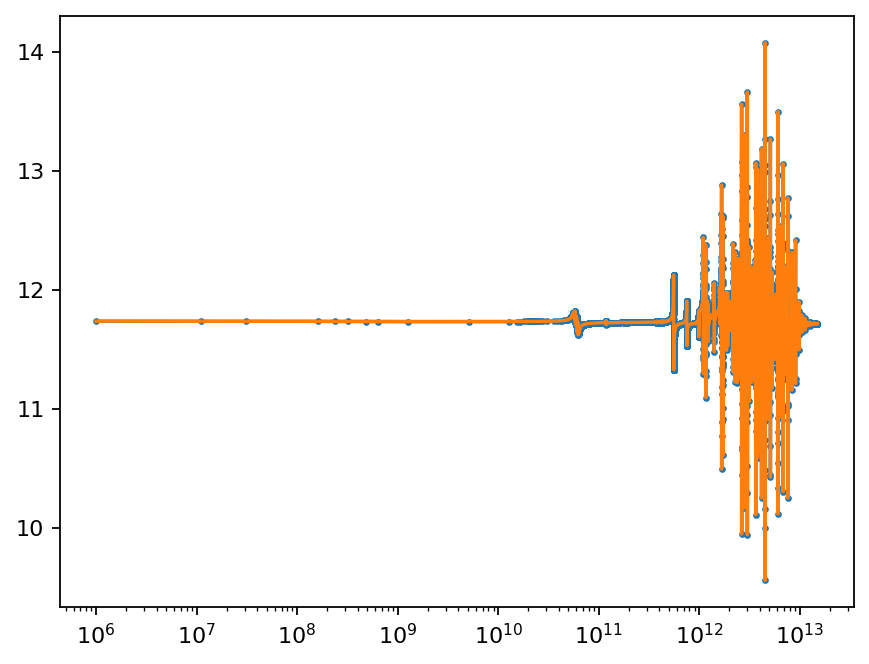

In [341]:
spec_slice = tuple([1, 0, 4, -1])

plt.plot(nu, spec[spec_slice])
plt.scatter(nu[include_nu_mask], spec[spec_slice][include_nu_mask], s=4)
plt.plot(nu, pred_spec[spec_slice])
# plt.xlim(50e9, 200e9)
# plt.ylim(0, 15)

# plt.xlim(1e13, 2e13)
# plt.ylim(0, 1)

plt.xscale("log")

In [136]:
include_nu_mask.sum() / include_nu_mask.size

np.float64(0.02408594064163024)

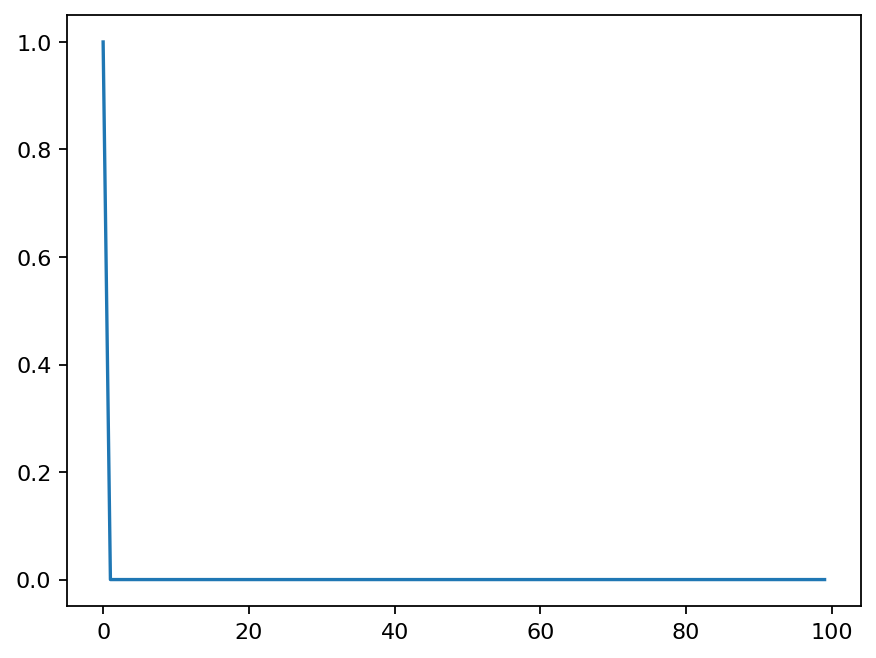

In [137]:
plt.plot(include_nu_mask[:100])

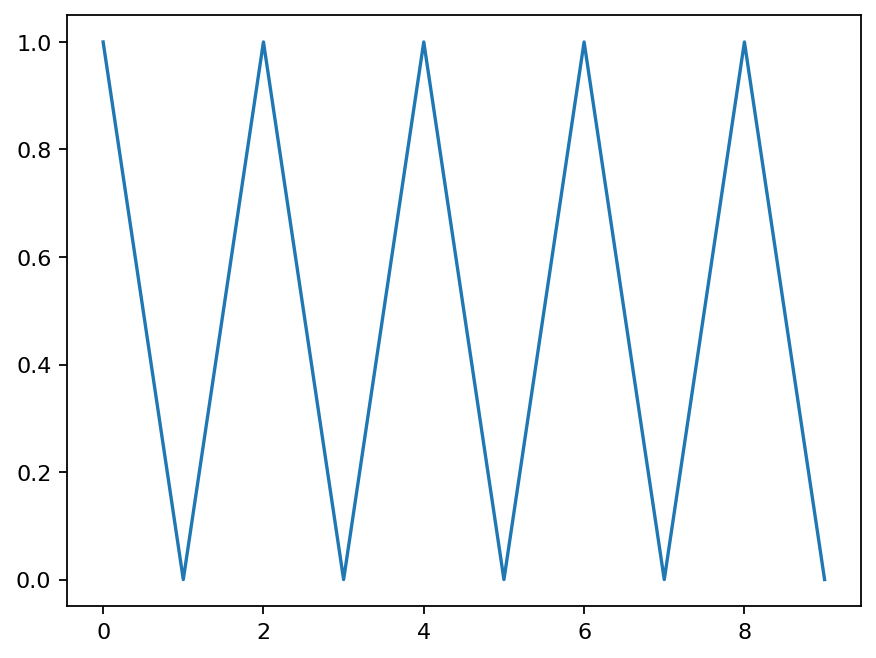

In [116]:
plt.plot(include_nu_mask[:10])

(50000000000.0, 70000000000.0)

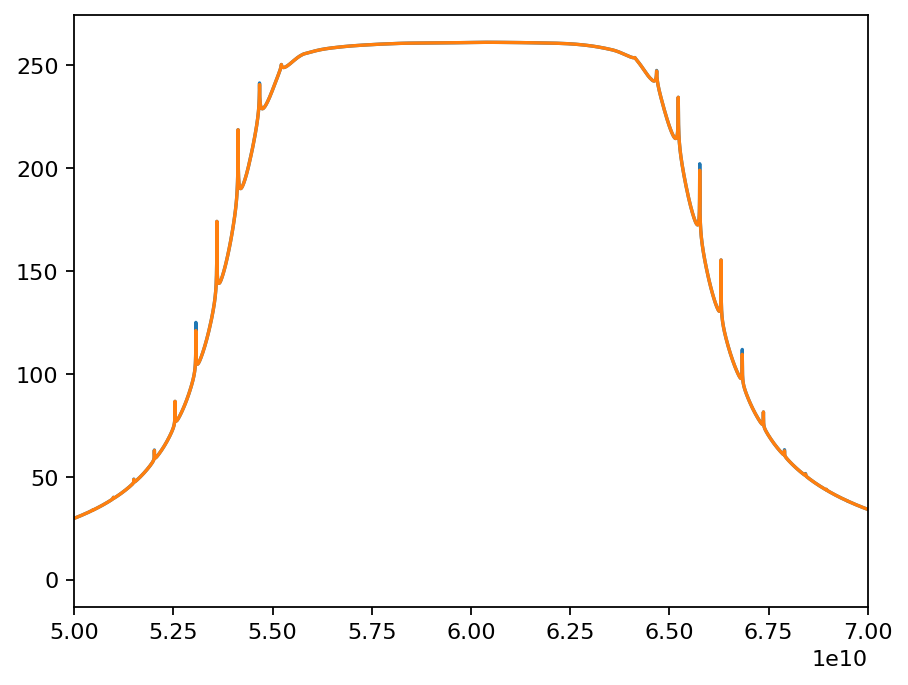

In [75]:
plt.plot(nu, spec)
plt.plot(nu, pred_spec)

plt.xlim(50e9, 70e9)

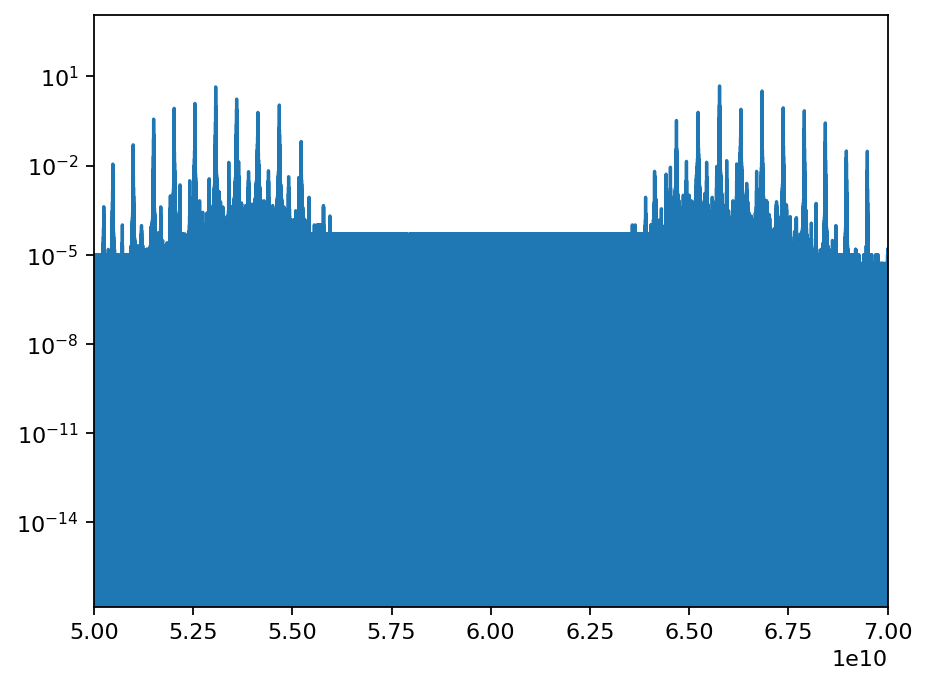

In [71]:
plt.plot(nu, np.abs(pred_spec - spec))

plt.xlim(50e9, 70e9)
plt.yscale("log")

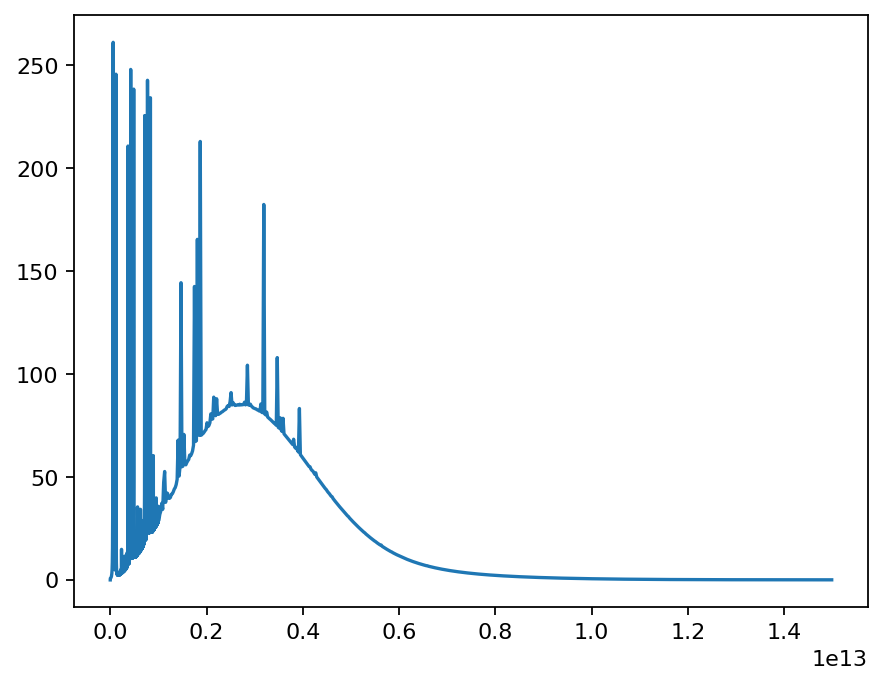

In [51]:
plt.plot(nu[nu_mask], data["temperature_rayleigh_jeans"][spec_slice][nu_mask])

In [43]:
# for nesting in range(max_nesting):


#     nu_index_mask 

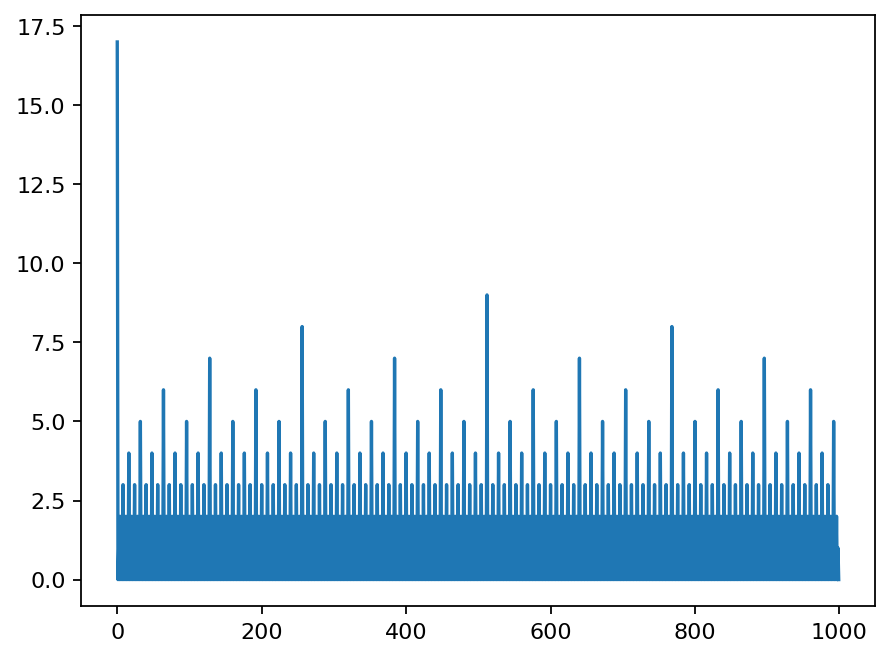

In [62]:
import matplotlib.pyplot as plt

plt.plot(np.abs(nu_index_nesting[:1000]))

In [30]:
data["temperature_rayleigh_jeans"][total_slice[:-1], sparse_nu_slice].shape, nu[sparse_nu_slice].shape

((4, 1, 9, 7, 191481), (95741,))

In [143]:
sparse_nu_mask = np.arange(len(nu)) % 2 == 0

max_errors = {"temperature_rayleigh_jeans": 1e-3}


key = "temperature_rayleigh_jeans"
# key = "opacity"

values = data[key]

sparse_nu = nu.copy()
sparse_values = values.copy()

In [239]:

sparse_nu_index = np.arange(len(nu))


In [256]:

candidates_to_remove = sparse_nu_index[1:-1:2]
test_nu_index = sparse_nu_index[~np.isin(sparse_nu_index, candidates_to_remove)]

pred_values = sp.interpolate.interp1d(nu[test_nu_index], 
                                      values[..., test_nu_index])(nu)

error = np.abs(values - pred_values)

keep = (error > max_error).any(axis=(0, 1, 2, 3))

keep_bin_index = np.digitize(np.where(keep)[0], bins=candidates_to_remove)

u = np.unique(list(set(keep_bin_index) | set(keep_bin_index + 1)))

indices_to_remove = candidates_to_remove[~np.isin(candidates_to_remove, u)]
sparse_nu_index = sparse_nu_index[~np.isin(sparse_nu_index, indices_to_remove)]

In [257]:
error[0,0,0, ]

array([[[[[0.00000000e+00, 4.96512687e-06, 9.22358375e-06, ...,
           2.57659000e-03, 1.43143500e-03, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          ...,
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

         [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.000000

In [249]:
u

array([24767, 24768, 25020, ..., 95739, 95740, 95741], shape=(10495,))

In [250]:
candidates_to_remove

array([     1,      3,      5, ..., 191475, 191477, 191479],
      shape=(95740,))

(20000000000.0, 350000000000.0)

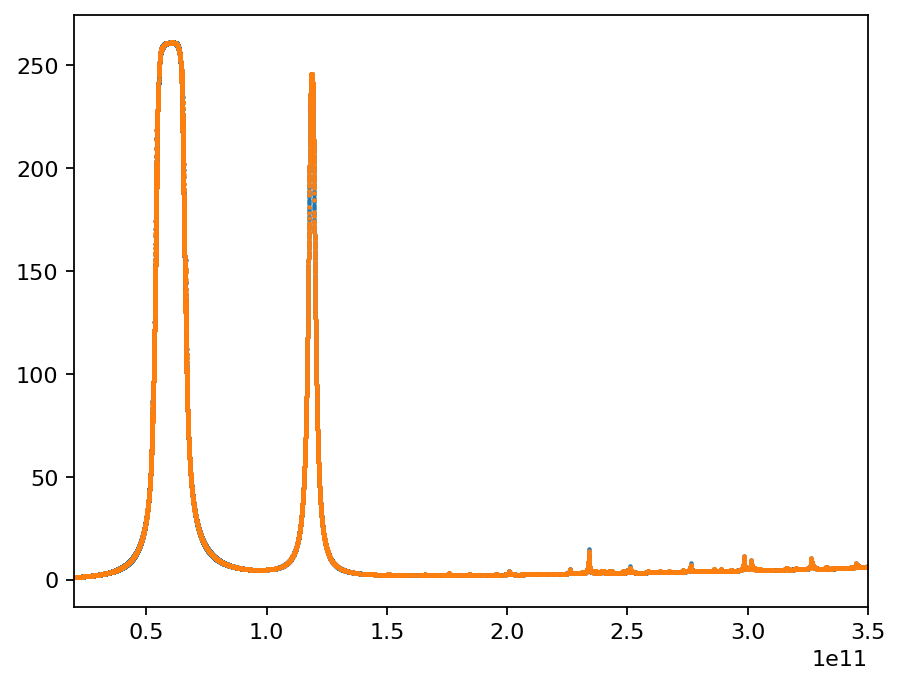

In [209]:
plt.scatter(nu, values[0,0,0,0], s=1)
plt.scatter(nu[sparse_nu_index], pred_values[0,0,0,0, sparse_nu_index], s=1)
plt.xlim(20e9, 350e9)

In [210]:
pred_values = sp.interpolate.interp1d(nu[sparse_nu_index], 
                                      values[..., sparse_nu_index])(nu)

error = np.abs(values - pred_values)

In [212]:
error.max(axis=(0, 1, 2, 3)).argmax()

np.int64(115509)

In [216]:
y = values[0,0,0,0]

np.gradient()

array([5.382121e-05, 6.375602e-05, 7.439750e-05, ..., 3.678728e-02,
       3.293922e-02, 3.453062e-02], shape=(191481,))

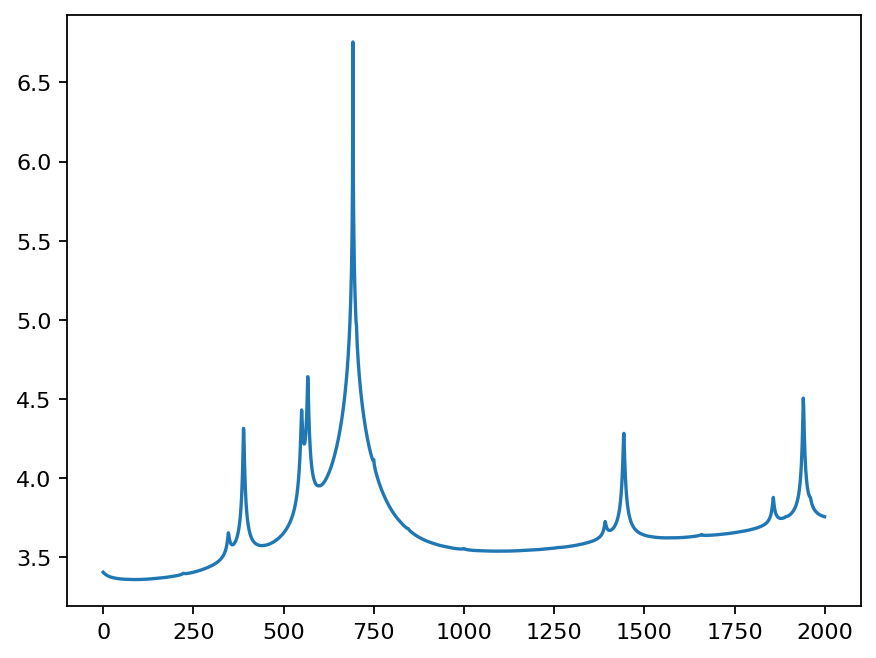

In [217]:
plt.plot(values[0,0,0,0,115509-1000:115509+1000])

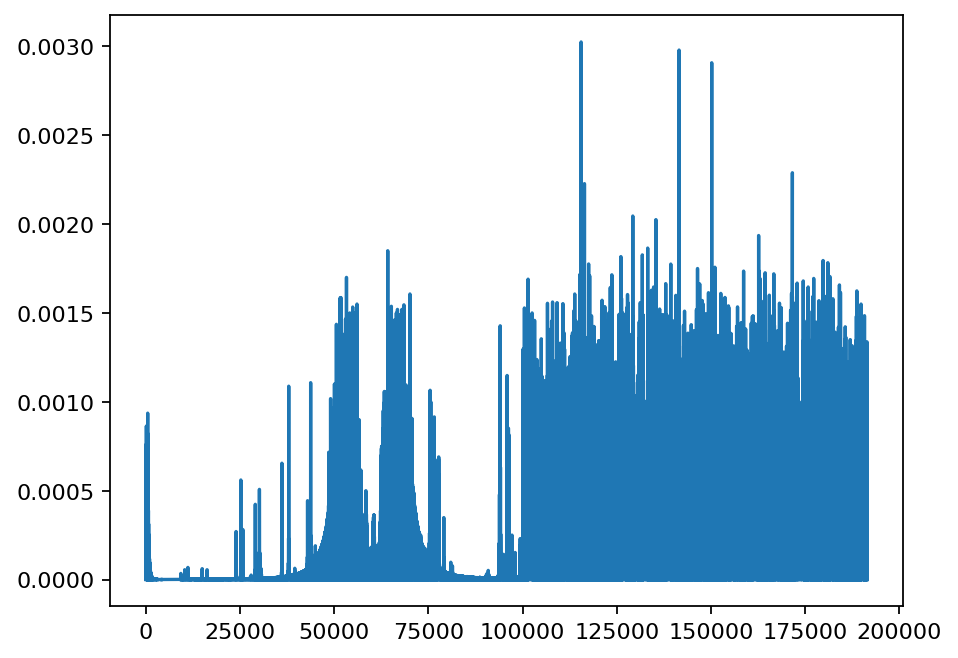

In [211]:
plt.plot(error.max(axis=(0, 1, 2, 3)))

In [173]:
sparse_nu_index

array([     0,      8,     16, ..., 191478, 191479, 191480],
      shape=(48371,))

In [129]:
# sparse_nu_mask = np.ones(len(nu), dtype=bool)
sparse_nu_index = np.arange(len(nu))

max_error = max_errors[key]

# we might remove these
candidates_sparse_index = [0, *sparse_nu_index[1:-1:2], -1]

# test_nu_index = sparse_nu_index[candidates_to_remove]

pred_values = sp.interpolate.interp1d(nu[candidate_sparse_index], 
                                      values[..., candidate_sparse_index])(nu)
error = np.abs(values - pred_values)

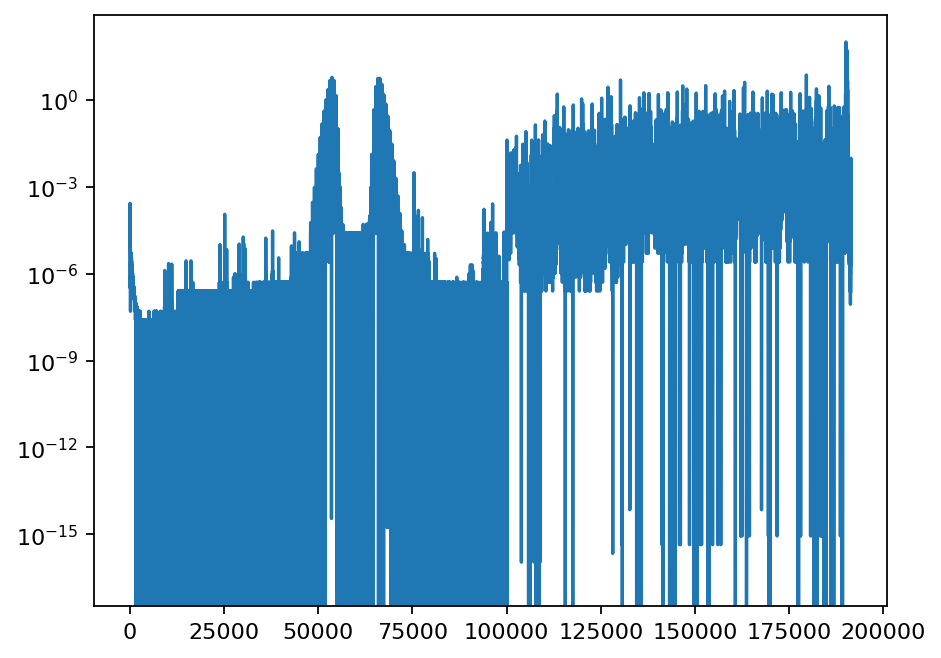

In [148]:
d_nu = np.gradient(sparse_values, axis=-1) #/ np.gradient(sparse_nu, axis=-1)
d2_nu = np.gradient(d_nu, axis=-1) #/ np.gradient(sparse_nu, axis=-1)

plt.plot(np.abs(d2_nu)[0,0,0,0])
plt.yscale("log")

In [135]:
error_ok = (error < max_error).all(axis=(0, 1, 2, 3))


In [133]:
error.max(axis=(0, 1, 2, 3)).shape

(191481,)

[]

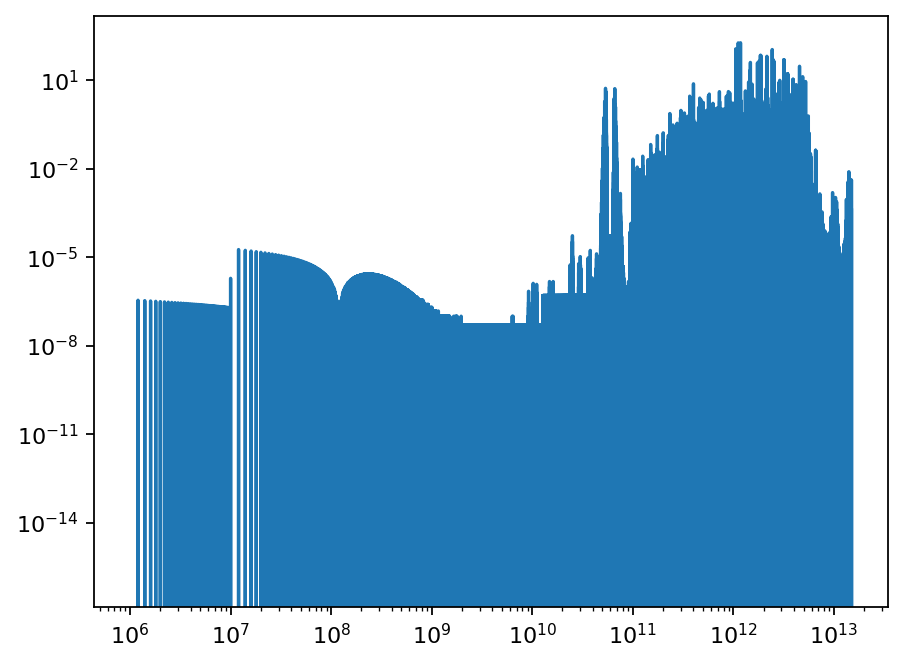

In [137]:
plt.plot(nu, error.max(axis=(0, 1, 2, 3)))
plt.loglog()

In [81]:
import sys

sys.getsizeof(values)

579038720

In [96]:



pred_values = 0.5 * (values[..., 2:] + values[..., :-2])
error = np.abs(values[..., 1:-1] - pred_values)

sparse_nu_mask = [True, *(error > max_errors[key]).any(axis=(0, 1, 2, 3)), True]

# if the error for a point is low enough
# then it is accurately interpolated by its neighbors
# and hence we can ignore it



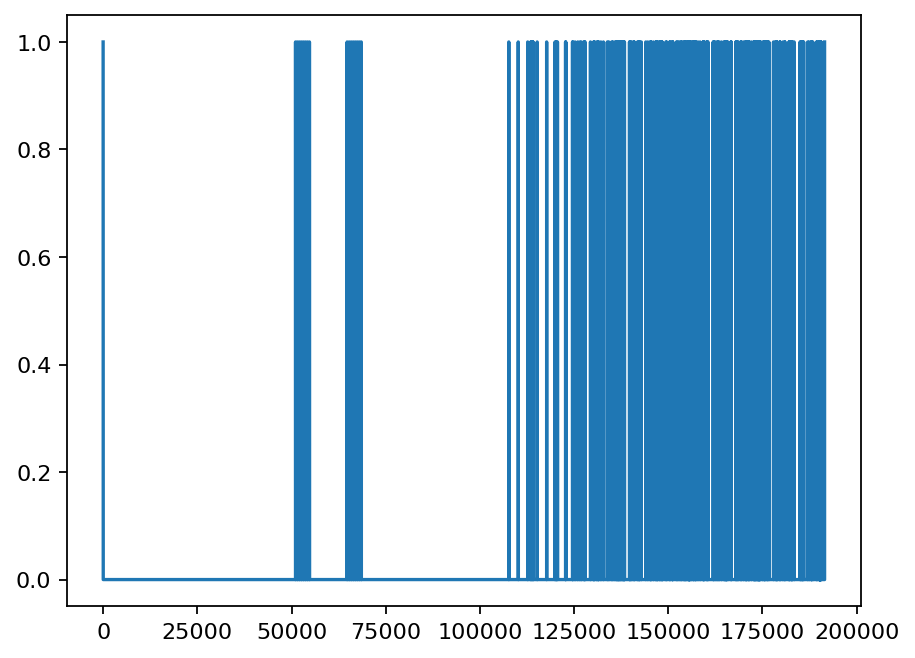

In [97]:
plt.plot(sparse_nu_mask)

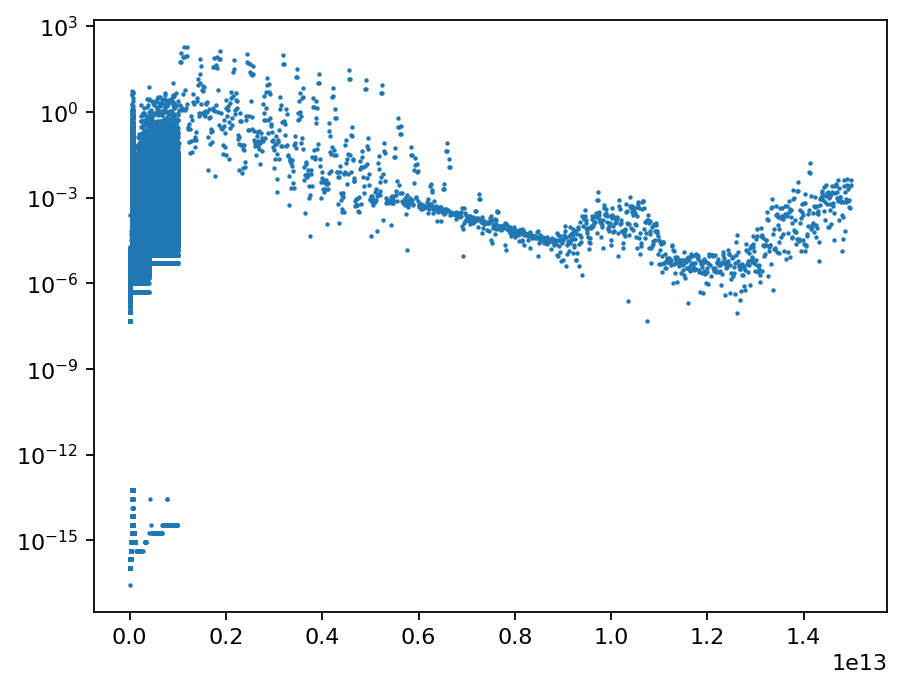

In [85]:
plt.scatter(nu[1:-1], error[0,0,0,0], s=1)
# plt.xlim(160e9, 210e9)
plt.yscale("log")

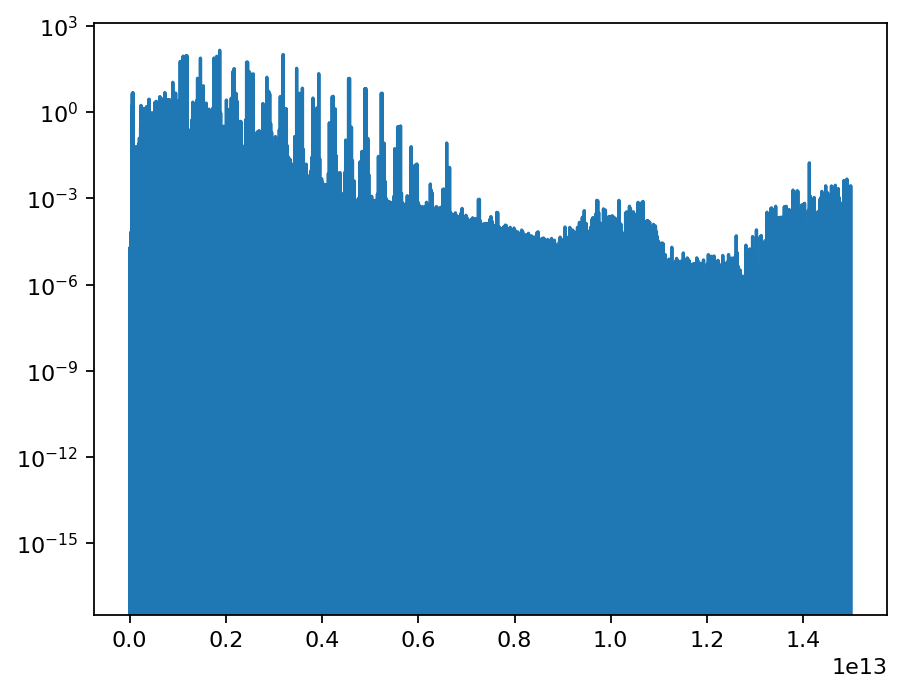

In [45]:
plt.plot(nu, np.abs(values - pred_values)[0,0,0,0])
plt.yscale("log")

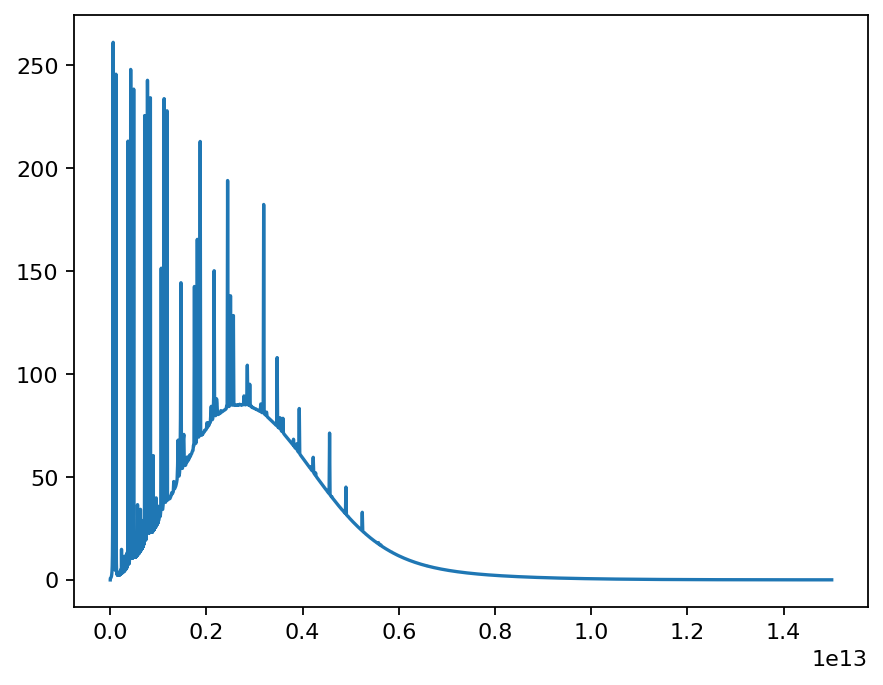

In [24]:
plt.plot(nu, data["temperature_rayleigh_jeans"][total_slice[:-1]])

In [46]:
self = w
w(pressure_level=w.pressure_level)

{'z': 4.398 km,
 'pressure': 60 kPa,
 'cloud_cover': array(0.),
 'cloud_ice_water': array(0.),
 'cloud_liquid_water': array(0.),
 'cloud_rain_water': array(0.),
 'cloud_snow_water': array(0.),
 'divergence': array(3.61756815e-05),
 'geopotential': 4.314e+04 m^2 s^-2,
 'humidity': array(0.),
 'ozone': 3.936e-08 kg m^-3,
 'potential_vorticity': array(2.17852005e-07),
 'relative_vorticity': array(6.83983417e-05),
 'temperature': 265.3 K,
 'wind_east': 2.036 m/s,
 'wind_north': -189 mm/s,
 'wind_speed': 2.044 m/s,
 'wind_vertical': -410.2 mm/s,
 'water_vapor': 0 kg m^-3,
 'air_density': 0.7879 kg m^-3,
 'dew_point': 99.89 K}

In [47]:
import matplotlib.pyplot as plt

# plt.plot(w.pressure.Pa, w.air_density.to("kg/m^3"))

In [15]:
decade

{'f_min': 100 GHz,
 'f_max': 1000 GHz,
 'f_step': 10 MHz,
 'n': 90000,
 'start_index': 100080}

In [48]:
decade["start_index"]:

'/users/tom/am-14.0/src/am'

In [14]:



spec

{'nu': [100.   100.01 100.02 ... 999.97 999.98 999.99] GHz,
 'temperature_rayleigh_jeans': [ 4.967249  4.968846  4.970465 ... 28.65829  28.65252  28.64697 ] K_RJ,
 'opacity': array([0.02148069, 0.02148826, 0.02149595, ..., 0.1443348 , 0.1443025 ,
        0.1442715 ], shape=(90000,)),
 'path_delay': [1.361894 1.36189  1.361891 ... 1.361804 1.361804 1.361802] m}

In [65]:
import sys

sys.getsizeof(spec["nu"].GHz)

720112

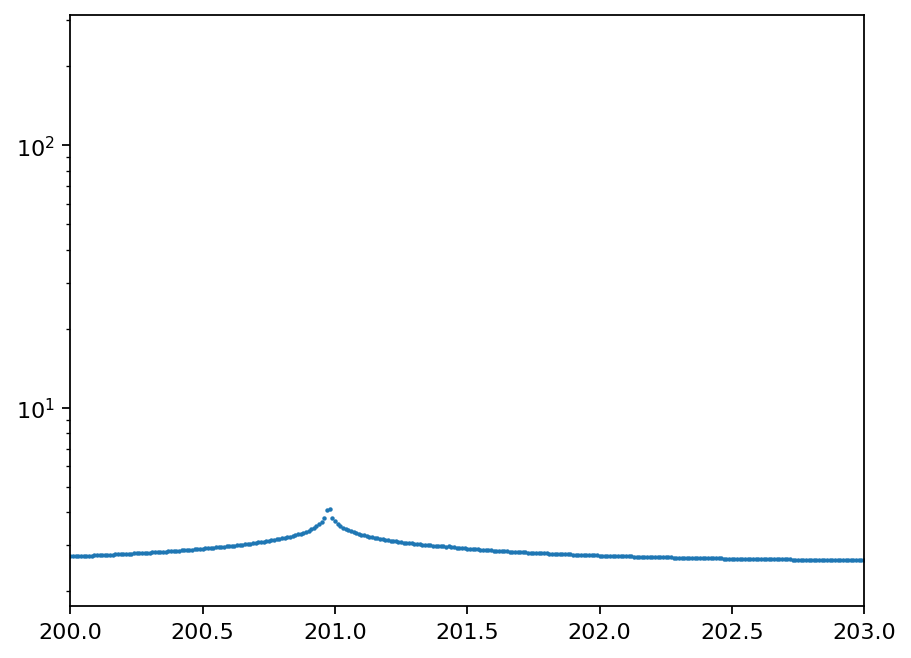

In [62]:
plt.scatter(spec["nu"].GHz, spec["temperature_rayleigh_jeans"].K_RJ, s=1)
plt.xlim(200, 203)
plt.yscale("log")

In [50]:
pathlib.Path(f"/tmp/am/{region}").mkdir(parents=True, exist_ok=True)
config_path = f"/tmp/am/{region}/config.amc"
with open(config_path, "w") as f:
    f.write(c)

start_time = time.monotonic()
fails = 0

while fails < 7:
    try:
        proc = subprocess.run([AM_PATH, config_path], capture_output=True, text=True)
        spec = pd.DataFrame(np.array(proc.stdout.split()).reshape(-1, 4).astype(float), columns=["nu", "trj", "tau", "L"])
        # zpwvstr, lospwvstr = re.findall(r"# *\((.+) um_pwv\) *\((.+) um_pwv\) *", proc.stderr)[0]
        # zpwv, lospwv = float(zpwvstr), float(lospwvstr)

        # TAU[i_alt, i_bt, i_pwv, i_el, start_index:start_index+n] = spec.tau
        # TRJ[i_alt, i_bt, i_pwv, i_el, start_index:start_index+n] = spec.trj
        # L[i_alt, i_bt, i_pwv, i_el, start_index:start_index+n] = spec.L

        break
    except Exception as e:
        print(e)
        print()
        print(proc.stderr)
        time.sleep(1e0)
        fails += 1
else:
    raise ValueError("Too many fails.")

In [23]:
spec.shape

(90, 4)

[]

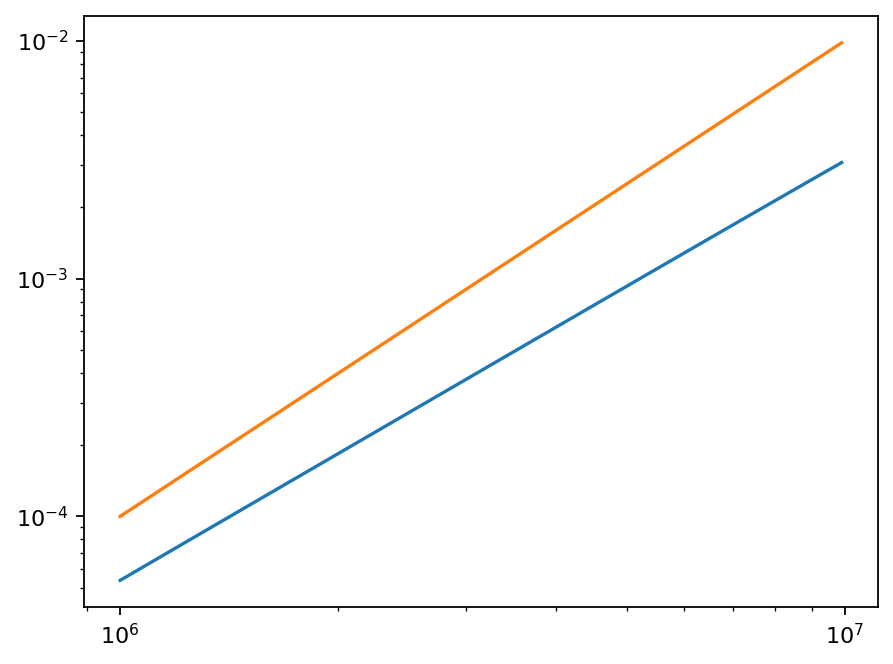

In [22]:
plt.plot(spec.nu, spec.trj)
plt.plot(spec.nu, 1e-16 * spec.nu ** 2)
plt.loglog()

In [19]:
# print(c)?

In [31]:
temperature_quantile = 0.5

w = Weather(region,  
            pressure_level=pressure_level,
            diurnal=False,
            seasonal=False,
            quantiles={"temperature": temperature_quantile}, override={"pwv": pwv})

w.data["levels"]["temperature"]

self = w
w

Weather:
  region: chajnantor
  time: Sep 2 15:03:52 -04:00
  altitude: 4.398 km
  pressure_level: 600 hPa
  base_temperature: 275.3 K
  pwv: 0 m

In [20]:
self.dew_point

[101.5589 101.478  101.3951 101.3101 101.2228 101.1307 101.037  100.9428
 100.8429 100.738  100.6308 100.4112 100.1683  99.8915  99.4815  99.0807
  98.6179  98.0482  97.3623  96.5507  95.5596  94.9811  94.3422  93.6834
  92.9695  92.3255  91.6832  92.1627  93.2644  94.1863  94.7672  95.7849
  96.3714  97.0474  98.1413  98.7848  98.9313] K

In [6]:
from maria.constants import c, k_B

Quantity(2.998e8, "m s^-1"), Quantity(k_B, "J/K")

(299.8 Mm/s, 1.381e-23 K^-1 kg m^2 s^-2)

[100.   97.5  95.   92.5  90.   87.5  85.   82.5  80.   77.5  75.   70.
  65.   60.   55.   50.   45.   40.   35.   30.   25.   22.5  20.   17.5
  15.   12.5  10.    7.    5.    3.    2.    1.    0.7   0.5   0.3   0.2
   0.1] kPa

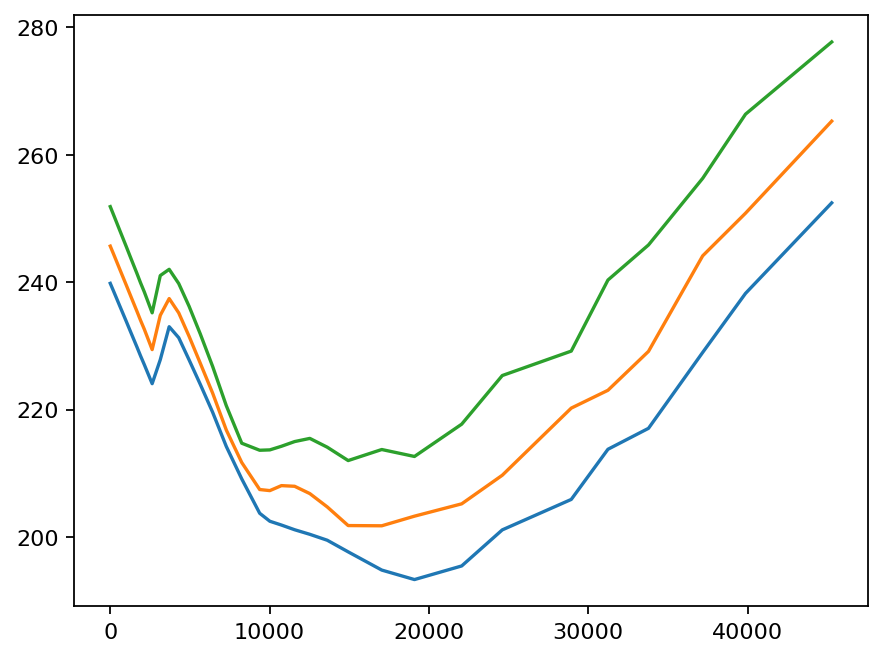

In [28]:
import matplotlib.pyplot as plt

region = "south_pole"



for temperature in [0.1, 0.5, 0.9]:
    w = Weather(region, 
                pressure_level=550,
                diurnal=False,
                seasonal=False,
                quantiles={"temperature": temperature}, override={"pwv": 1})
    
    plt.plot(w.z.m, w.temperature.K)

In [14]:
self = w
key = "temperature"




# level_quantile_values = sp.interpolate.interp1d(self.qdata["metadata"]["side_pressure"],
#                                                 median_values)(self.pressure_level.Pa)

# base_value = 

# sp.interpolate.interp1d(level_quantile_values, self.qdata["metadata"]["side_quantile"])(5.6)

In [30]:
w = Weather(region, 
            pressure_level=80,
            diurnal=False,
            seasonal=False,
            quantiles={"temperature": 0.5})



# w.compute_base_global_quantiles(["temperature"])

{'temperature': 0.5}

In [16]:
self.temperature[self.base_pressure_index]

267.1 K

In [ ]:
w = 

In [14]:
# read_weather_quantile_data(self.cache_path)

In [16]:
%time self.base_pressure_index

CPU times: user 9.34 ms, sys: 3.1 ms, total: 12.4 ms
Wall time: 11.6 ms


np.int64(14)

In [12]:
%time g = self(altitude=self.altitude, fields=["temperature"])

CPU times: user 9 μs, sys: 1 μs, total: 10 μs
Wall time: 15.3 μs


NameError: name 'self' is not defined

In [18]:
level_quantile_values

array([5.56445646, 5.57869673, 5.58515596, 5.58830357, 5.59537506,
       5.60007477, 5.60457993, 5.61057472, 5.61311817, 5.61794853,
       5.62611866])

In [247]:
[5, 10, 15, 20, 30, 40, 60, 90][::-1]

[90, 60, 40, 30, 20, 15, 10, 5]

In [189]:
first_level_index = np.where(self.pressure > self.pressure_level)[0][-1] - 1

In [190]:
decades[5]

{'f_min': 100000000000,
 'f_max': 999990000000,
 'f_step': 10000000,
 'n': 90000,
 'start_index': 100080}

In [35]:

self = w

layer_configs = []

decade = decades[5]

f_min = decade['f_min']
f_max = decade['f_max']
f_step = decade['f_step']
el = 45


    
# for decade_index, decade in enumerate(decades):

    
    
    # c = am_config(self, f_min)

In [36]:
config = "\n\n".join(config_parts)

NameError: name 'config_parts' is not defined

In [37]:
c = am_config(self, f_min=decade["f_min"], f_max=decade["f_max"], f_step=decade["f_step"], el=45)



In [15]:
spec

,nu,trj,tau,L


In [ ]:
plt.plot(1e-9 * spec.nu, spec.L.values.astype(np.float32))
plt.xlim(40, 350)

In [175]:
proc = subprocess.run([AM_PATH, config_path], capture_output=True, text=True)
spec = pd.DataFrame(np.array(proc.stdout.split()).reshape(-1,4).astype(float), columns=["nu", "trj", "tau", "L"])

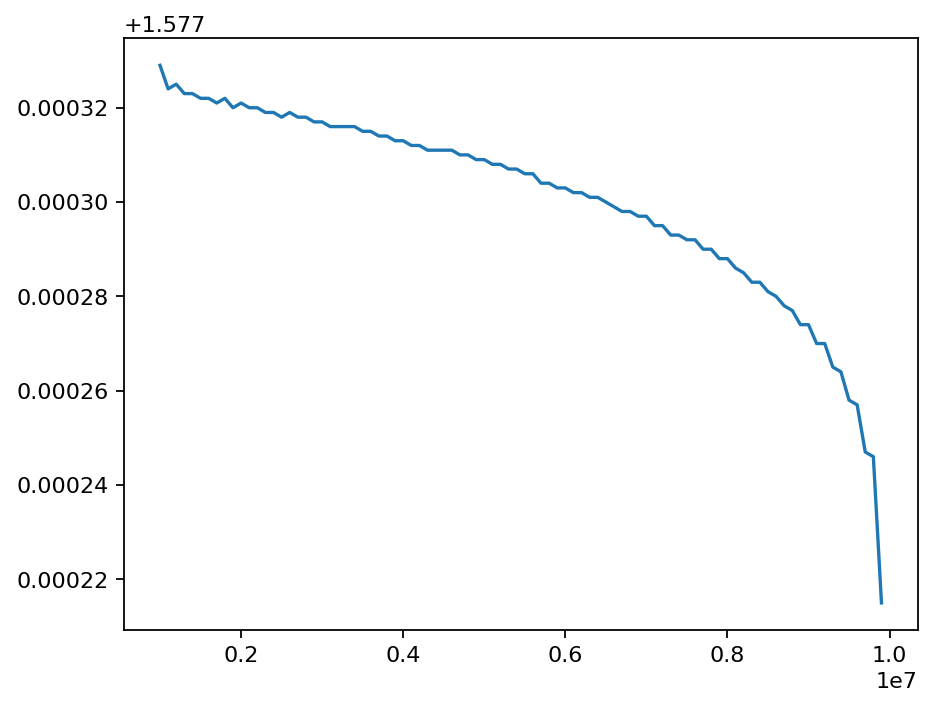

In [63]:
import matplotlib.pyplot as plt

plt.plot(spec.nu.values, spec.L.values)

In [7]:
# from maria.atmosphere import Atmosphere, AtmosphericSpectrum

# atmosphere = Atmosphere(region="algonquin")

In [8]:
w.data["levels"]["humidity"].shape

(37,)

In [9]:

# mask = h_data < 1e4 #h_data.min() + 5e3

for k, data in d.items():

    linear = lambda x, a, b: a * x + b
    pars, cpars = sp.optimize.curve_fit(linear, h_data[mask], data[mask])
    
    h_interp = [0, *h_data]
    d_interp = [linear(0, *pars), *data]
    
    profiles[k][region] = np.interp(h_master, h_interp, d_interp)

# for key in ["pressure", "absolute_humidity"]:
#     profiles[key][region] = np.exp(profiles[key].pop(region))

    

NameError: name 'd' is not defined

In [25]:
list(side_quantile).index(0.5)

5

In [ ]:
mean_altitude = 

In [32]:
region_median_level_altitude = np.median(quantiles["geopotential"][..., list(side_quantile).index(0.5)], axis=(0, 1)) / g

region_median_level_altitude

array([  125.13450374,   334.97937076,   548.68991796,   768.32621435,
         991.89339252,  1217.59958823,  1451.13329643,  1689.30293328,
        1937.7452105 ,  2189.00226497,  2450.15534228,  2991.51247199,
        3569.29237776,  4188.3572492 ,  4855.36471275,  5570.85648461,
        6354.97874096,  7205.12283194,  8136.84381396,  9181.53022372,
       10380.95217215, 11053.95205764, 11804.44080757, 12658.07384193,
       13643.9831753 , 14805.74255166, 16230.26046303, 18477.96969628,
       20573.63925768, 23816.97380686, 26391.80478127, 30893.25550588,
       33220.81169708, 35497.08572784, 39158.12467477, 42212.08519606,
       47522.96107509])

In [52]:

pressure_samples

array([100000.,  89910.,    100.])

In [53]:
# sp.interpolate.interp1d(region_median_level_altitude, side_pressure)([region_entry.min_altitude, region_entry.max_altitude])

In [56]:
if region_entry.max_altitude - region_entry.min_altitude <= 1e3:
    altitude_samples = [region_entry.min_altitude, region_entry.max_altitude]
else:
    altitude_samples = [region_entry.min_altitude, region_entry.altitude, region_entry.max_altitude, ]
    
zenith_pwv_samples = [0, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0] # in mm
temperature_offset = [-1, 1] # in celsius
elevation_samples = [5, 10, 20, 30, 40, 50, 70, 90] # in degrees

altitude_samples = [region_median_level_altitude.min(), 
                    region_entry.max_altitude,
                    region_median_level_altitude.max()]
pressure_samples = sorted(sp.interpolate.interp1d(region_median_level_altitude, 
                                                  side_pressure)(altitude_samples).round()) # in 


print(zenith_pwv_samples)
print(base_temperature_samples)
print(elevation_samples)
print(pressure_samples)

[0, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
[211.759729  254.3545033]
[5, 10, 20, 30, 40, 50, 70, 90]
[np.float64(100.0), np.float64(89910.0), np.float64(100000.0)]


In [ ]:
np.digitize(side_pressure)

In [ ]:

# h_from_canonical = np.linspace(region_entry.altitude, h_data.max(), 1024)
# w_from_canonical = np.interp(h_from_canonical, h_master, profiles["absolute_humidity"][region])

# typical_pwv = np.trapezoid(w_from_canonical, x=h_from_canonical)



# pwv_scales = zenith_pwv_samples / typical_pwv

# base_pressure_samples = np.percentile(quantiles["temperature"][..., 0], q=[0, 50, 100])
# elevation_samples = np.linspace(5, 90, 18)
# elevation_samples = np.linspace(10, 90, 9)

TRJ = np.zeros((
            len(altitude_samples),
            len(base_temperature_samples),
            len(zenith_pwv_samples), 
            len(elevation_samples),
            len(nu)))
TAU = np.zeros(TRJ.shape)
L = np.zeros(TRJ.shape)

total_spectra = np.prod(TRJ.shape[:-1]) * len(decades)
i_spectrum = 0


region_start = time.monotonic()

for i_alt, alt in enumerate(altitude_samples):

    layer_boundaries = [alt]

    while max(layer_boundaries) < h_master.max():

        layer_res = np.interp(layer_boundaries[-1], 
                              [alt, h_master.max()], 
                              [100, 2000])

        layer_boundaries.append(layer_boundaries[-1] + layer_res)

    layer_boundaries = np.array(layer_boundaries)
    layer_middles = (layer_boundaries[1:] + layer_boundaries[:-1]) / 2
    layer_abs_hum = np.interp(layer_middles, h_master, profiles["absolute_humidity"][region])
    typical_pwv_per_layer = np.diff(layer_boundaries) * layer_abs_hum

    layer_tbase = np.interp(layer_boundaries[1:], h_master, profiles["temperature"][region])
    layer_pbase = np.interp(layer_boundaries[1:], h_master, profiles["pressure"][region])
    layer_ozone = (28.96 / 48) * np.interp(layer_boundaries[1:], h_master, profiles["ozone"][region])
    
    for i_bt, bt in enumerate(base_temperature_samples):      
        for i_pwv, pwv in enumerate(zenith_pwv_samples):
            for i_el, el in enumerate(elevation_samples):

                layer_tbase = layer_tbase + bt - layer_tbase[0]
                layer_pwvs = typical_pwv_per_layer * (pwv / typical_pwv_per_layer.sum())

                for i_decade, decade in enumerate(decades):

                    start_index, n = decade["start_index"], decade["n"]

                    config_header = f"""
    f {decade['f_min']} Hz {decade['f_max']} Hz {decade['f_step']} Hz
    output f Hz Trj K tau neper L m
    tol 0
    za {90 - el} deg
    T0 0 K
    """
                    layer_configs = []

                    for i_layer, hbase in enumerate(layer_boundaries[1:]):

                        layer_configs.append(f"""
    layer
    Pbase {layer_pbase[i_layer]:.01f} Pa
    Tbase {layer_tbase[i_layer]:.01f} K
    column h2o {1e3 * layer_pwvs[i_layer]:.03f} um_pwv
    column o3 vmr {layer_ozone[i_layer]:.01e}
    column dry_air vmr""")

                    config_text = config_header + "\n".join(layer_configs[::-1])
        
                    pathlib.Path(f"/tmp/am/{region}").mkdir(parents=True, exist_ok=True)
                    config_path = f"/tmp/am/{region}/config.amc"
                    with open(config_path, "w") as f:
                        f.write(config_text)

                    start_time = time.monotonic()
                    fails = 0

                    while fails < 7:
                        try:
                            proc = subprocess.run([AM_PATH, config_path], capture_output=True, text=True)
                            spec = pd.DataFrame(np.array(proc.stdout.split()).reshape(-1,4).astype(float), columns=["nu", "trj", "tau", "L"])
                            # zpwvstr, lospwvstr = re.findall(r"# *\((.+) um_pwv\) *\((.+) um_pwv\) *", proc.stderr)[0]
                            # zpwv, lospwv = float(zpwvstr), float(lospwvstr)

                            TAU[i_alt, i_bt, i_pwv, i_el, start_index:start_index+n] = spec.tau
                            TRJ[i_alt, i_bt, i_pwv, i_el, start_index:start_index+n] = spec.trj
                            L[i_alt, i_bt, i_pwv, i_el, start_index:start_index+n] = spec.L

                            break
                        except Exception as e:
                            print(e)
                            print()
                            print(proc.stderr)
                            time.sleep(1e0)
                            fails += 1
                    else:
                        raise ValueError("Too many fails.")

                    i_spectrum += 1

                    mtpl = (time.monotonic() - region_start) / i_spectrum

                    expected_finish_time = region_start + total_spectra * mtpl

                    logger_data = {"region": region,
                                   "alt": f"{alt} m",
                                   "base_temp": f"{bt:.1f} K",
                                   "pwv": f"{pwv:.02f} mm",
                                   "elev": f"{el} deg",
                                   "nu": f"{decade['f_min']:.01e}Hz-{decade['f_max']:.01e}Hz",
                                   "duration": f"{time.monotonic() - start_time:.02f}",
                                   "etr": f"{expected_finish_time - time.monotonic():.1f} s"}
                    
                    logger.info(" | ".join([f"{k}={v}" for k, v in logger_data.items()]) + f" | {i_spectrum} / {total_spectra}")



spectra_data["side_nu_Hz"] = np.array(nu)
spectra_data["side_elevation_deg"] = np.array(elevation_samples)
spectra_data["side_zenith_pwv_mm"] = np.array(zenith_pwv_samples)
spectra_data["side_base_temperature_K"] = np.array(base_temperature_samples)
spectra_data["side_altitude_m"] = np.array(altitude_samples)
spectra_data["rayleigh_jeans_temperature_K"] = TRJ
spectra_data["opacity_nepers"] = TAU
spectra_data["excess_path_m"] = L


with h5py.File(write_path, "w") as f:

    for key in ["side_nu_Hz", "side_zenith_pwv_mm", "side_base_temperature_K", "side_elevation_deg", "side_altitude_m"]:

        f.create_dataset(key, data=spectra_data[key].astype(float), dtype="f")

    output_config = {
        "rayleigh_jeans_temperature_K": {"kwargs":{"scaleoffset": 4}},
        "opacity_nepers": {"kwargs":{"scaleoffset": 4}},
        "excess_path_m": {"kwargs":{"scaleoffset": 4}},
    }

    for key in output_config.keys():
        f.create_dataset(key, 
                         data=spectra_data[key],
                         dtype="f", 
                         compression="gzip", 
                         compression_opts=9)
    
